# Projet d'apprentissage - Détection de minerais dans Minecraft

Ultralytics :

https://docs.ultralytics.com/fr/#where-to-start

https://docs.ultralytics.com/usage/python/

https://docs.ultralytics.com/modes/predict/#working-with-results

Doc un peu + précise sur l'impl

https://docs.ultralytics.com/reference/engine/results/



Format YAML :

https://docs.ultralytics.com/fr/datasets/segment/#ultralytics-yolo-format


Analyse des résultats :

https://www.ultralytics.com/fr/glossary/confidence

https://www.ultralytics.com/fr/glossary/precision


Augmentation des données :

https://docs.ultralytics.com/guides/yolo-data-augmentation/#example-configurations


Datasets trucs :

https://docs.ultralytics.com/reference/data/dataset



In [ ]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.2 MB/s eta 0:00:00


In [ ]:
import PIL
from PIL import Image
import csv
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

from ultralytics import YOLO

import shutil
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Importation de la base de données**

Base de donnée disponible sur git et accessible via un .csv

In [ ]:
!rm -fr x-ray/
!rm -fr images/
!rm -fr labels/

!git clone https://github.com/maxens-git/x-ray

Cloning into 'x-ray'...
remote: Enumerating objects: 2285, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 2285 (delta 80), reused 142 (delta 64), pack-reused 2116 (from 2)
Receiving objects: 100% (2285/2285), 739.59 MiB | 31.79 MiB/s, done.
Resolving deltas: 100% (927/927), done.


In [ ]:
dataset = []
with open('x-ray/dataset/split.csv', newline='') as csvfile:
  filereader = csv.reader(csvfile, delimiter=' ')
  for row in filereader:
    data = row[0].split(',')
    if (data[0] != 'id'):
      width = int(data[4])
      heigh = int(data[5])
      path = data[2].split('/')
      box = [int(data[6])/width, int(data[7])/int(heigh), int(data[8])/int(width), int(data[9])/int(heigh)]
      new_entry = {'id': data[0], 'data': data[1], 'path': data[2], 'class': data[3], 'box': box, 'image_name': path[1]}
      dataset.append(new_entry)

print(dataset)

[{'id': '1', 'data': 'TEST', 'path': 'images/100_a_o_unknown.png', 'class': 'GOLD', 'box': [0.471875, 0.4166666666666667, 0.4921875, 0.45], 'image_name': '100_a_o_unknown.png'}, {'id': '2', 'data': 'TRAIN', 'path': 'images/101_a_fr_water.png', 'class': 'REDSTONE', 'box': [0.459375, 0.17777777777777778, 0.5234375, 0.2833333333333333], 'image_name': '101_a_fr_water.png'}, {'id': '3', 'data': 'TRAIN', 'path': 'images/101_a_fr_water.png', 'class': 'IRON', 'box': [0.0703125, 0.525, 0.1890625, 0.6694444444444444], 'image_name': '101_a_fr_water.png'}, {'id': '4', 'data': 'TRAIN', 'path': 'images/101_a_fr_water.png', 'class': 'IRON', 'box': [0.59375, 0.7444444444444445, 0.646875, 0.8222222222222222], 'image_name': '101_a_fr_water.png'}, {'id': '5', 'data': 'TRAIN', 'path': 'images/101_a_fr_water.png', 'class': 'IRON', 'box': [0.6515625, 0.8027777777777778, 0.703125, 0.8777777777777778], 'image_name': '101_a_fr_water.png'}, {'id': '6', 'data': 'VAL', 'path': 'images/102_a_rlf_water.png', 'class

In [ ]:
classes_indices = {'IRON': 0, 'COAL': 1, 'REDSTONE': 2,'GOLD': 3,'COPPER': 4,'LAPIS': 5, 'EMERALD': 6, 'DIAMOND': 7 ,'QUARTZ': 8, 'NETHERGOLD': 9, 'DEBRIS': 10}

**Préparation des données pour le modèle Yolo26 et la bibliothèque Ultralytics**

Pour traiter les images avec Yolo26 et la bibliothèque Ultralytics, nous devons les placer dans une structure de dossiers particulière :


*   Un dossier images/train pour les images d'entrainement
*   Un dossier images/val pour les images de validation
*   Un dossier images/test pour les images de test

et de même pour les informations des images :

*   Un dossier labels/train
*   Un dossier labels/val
*   Un dossier labels/test


In [ ]:
!mkdir -p images/train
!mkdir -p images/val
!mkdir -p images/test

for image in dataset:
    image_path = 'x-ray/dataset/' + image['path']

    if image['data'] == 'TRAIN':
        new_image_path = 'images/train/' + image['image_name']
        shutil.copy(image_path, new_image_path)
        #print('copie de ' + image_path + ' dans ' + new_image_path)

    elif image['data'] == 'VAL':
        new_image_path = 'images/val/' + image['image_name']
        shutil.copy(image_path, new_image_path)
        #print('copie de ' + image_path + ' dans ' + new_image_path)
    elif image['data'] == 'TEST':
        new_image_path = 'images/test/' + image['image_name']
        shutil.copy(image_path, new_image_path)
        #print('copie de ' + image_path + ' dans ' + new_image_path)
    else:
        print("Les problèmes...")

print('C\'est good')



C'est good


Une fois les images placées dans les bons dossiers, on doit placer leurs informations (comme la box par exemple) dans un dossier 'label'.

In [ ]:
!mkdir -p labels/train
!mkdir -p labels/val
!mkdir -p labels/test

images_annotations = {}

for image in dataset:
    image_name = image['image_name']

    if image_name not in images_annotations:
        images_annotations[image_name] = []

    images_annotations[image_name].append(image)

for image_name, image_list in images_annotations.items():

    if image_list[0]['data'] == 'TRAIN':
        path = 'labels/train/'
    elif image_list[0]['data'] == 'VAL':
        path = 'labels/val/'
    elif image_list[0]['data'] == 'TEST':
        path = 'labels/test/'
    else:
        print('les problèmes...')

    label_name = os.path.splitext(image_name)[0] + '.txt'
    full_path = path + label_name

    with open(full_path, 'w') as f:
        for item in image_list:
            xmin, ymin, xmax, ymax = item['box']
            class_id = classes_indices[item['class']]
            x = (xmin + xmax) / 2
            y = (ymin + ymax) / 2
            w = xmax - xmin
            h = ymax - ymin
            to_write = str(class_id) + ' ' + str(x) + ' ' + str(y) + ' ' + str(w) + ' ' + str(h) + '\n'
            f.write(to_write)

**Utilisation du modèle**

In [ ]:
!rm -fr runs

# Load a pretrained YOLO model (recommended for training)
model = YOLO("yolo26n.pt")



# Train the model using the 'x-ray.yaml' dataset for 3 epochs
results = model.train(data="x-ray/dataset/x-ray.yaml", epochs=10, auto_augment=None, save_json=True)

# Evaluate the model's performance on the validation set
results = model.val()

'''
# Perform object detection on an image using the model
results = model("https://ultralytics.com/images/bus.jpg")

# Export the model to ONNX formatf
success = model.export(format="onnx")
'''

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=x-ray/dataset/x-ray.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

'\n# Perform object detection on an image using the model\nresults = model("https://ultralytics.com/images/bus.jpg")\n\n# Export the model to ONNX formatf\nsuccess = model.export(format="onnx")\n'

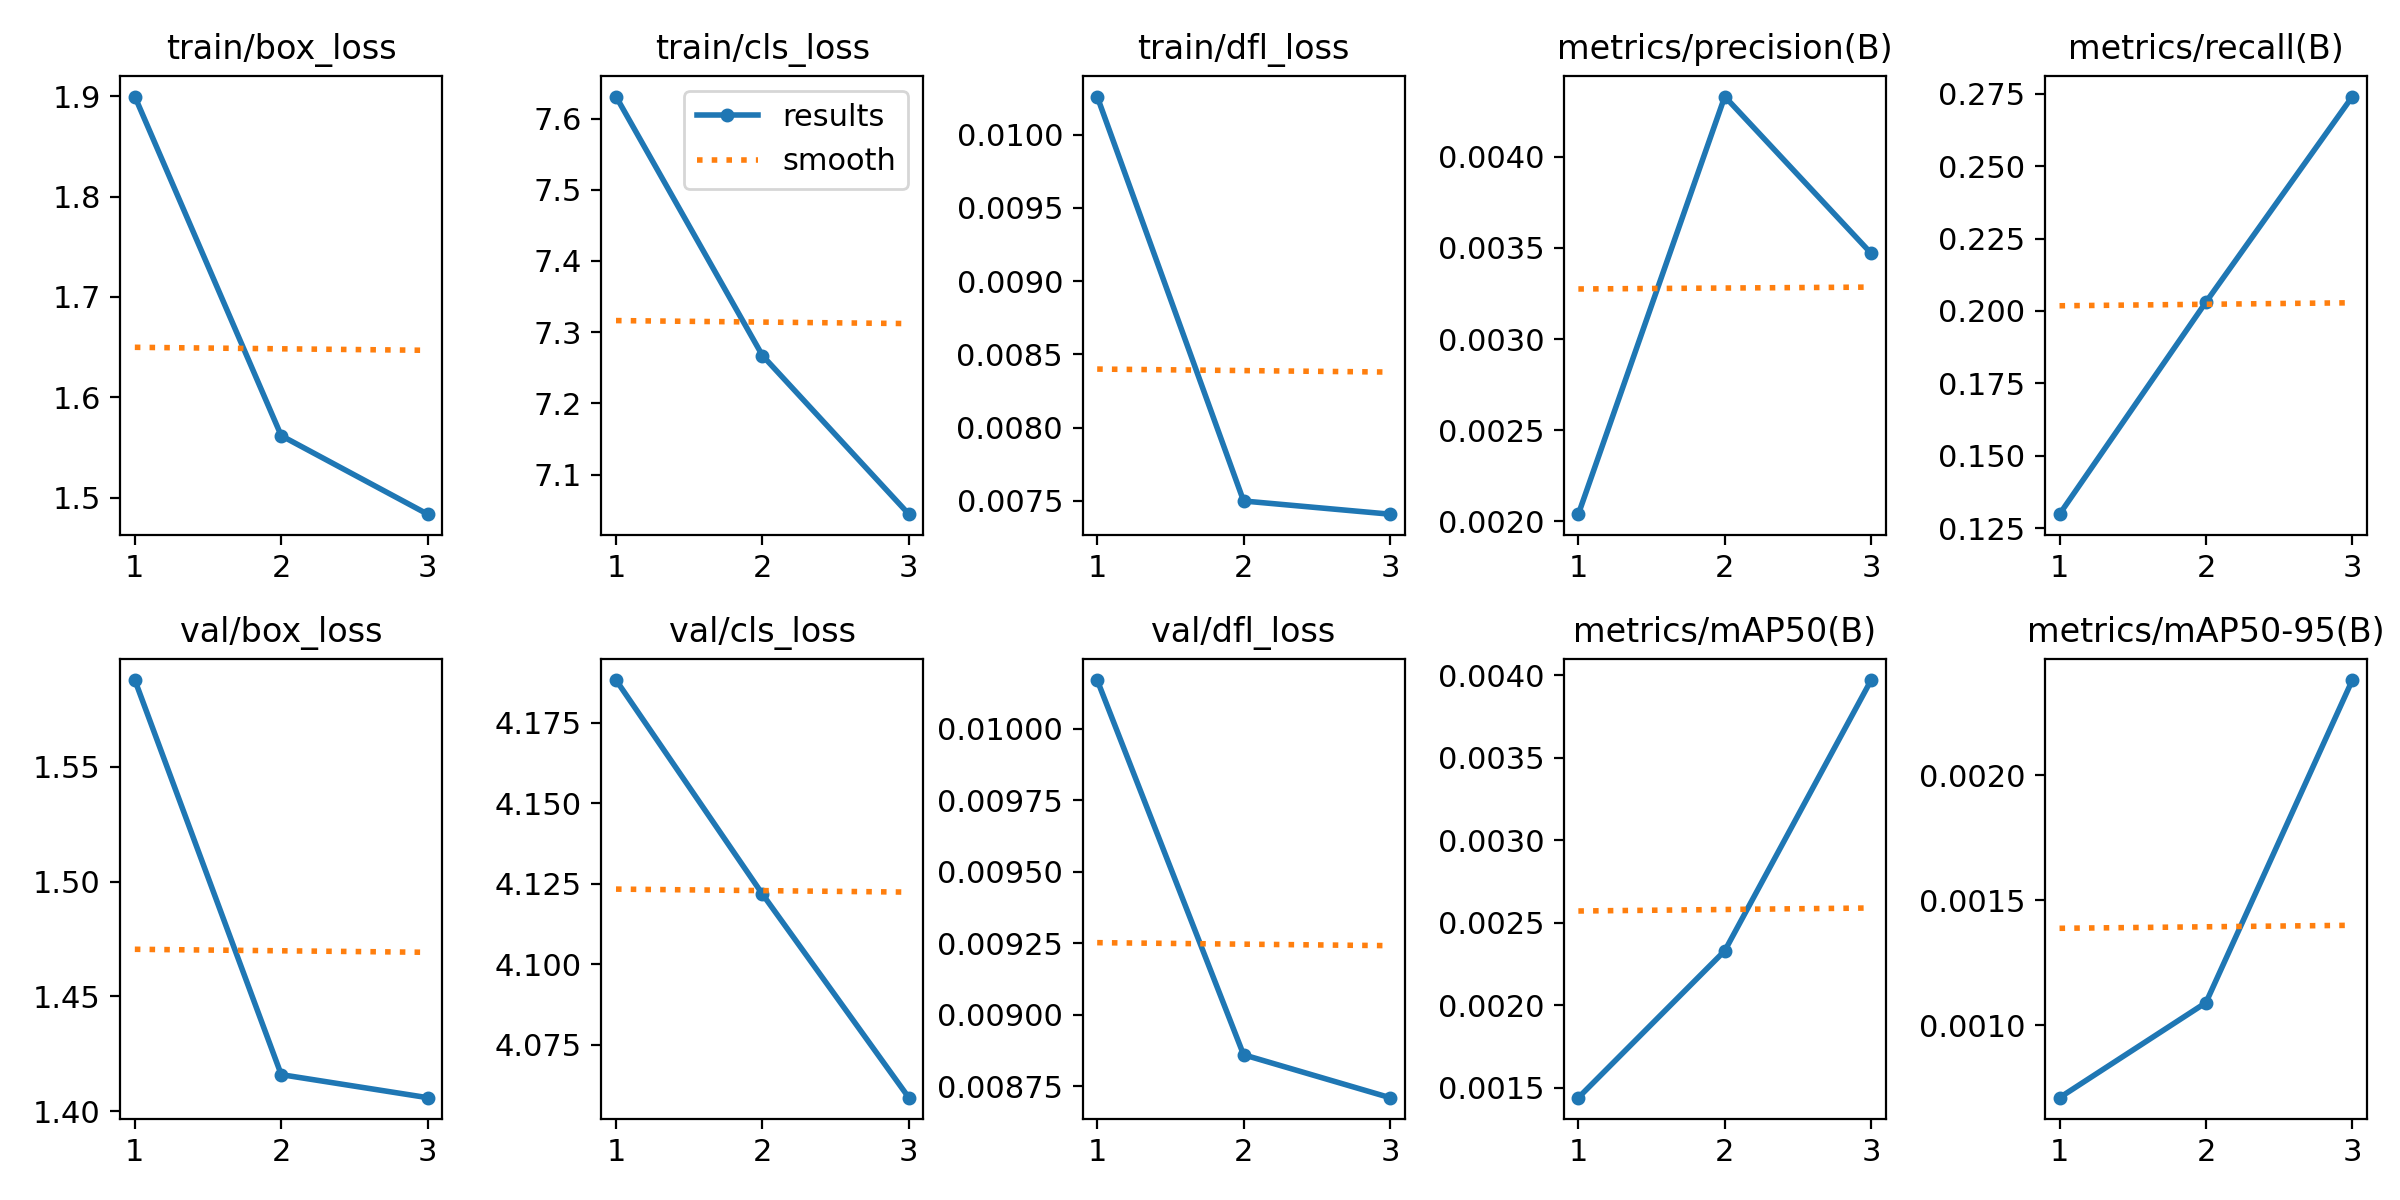

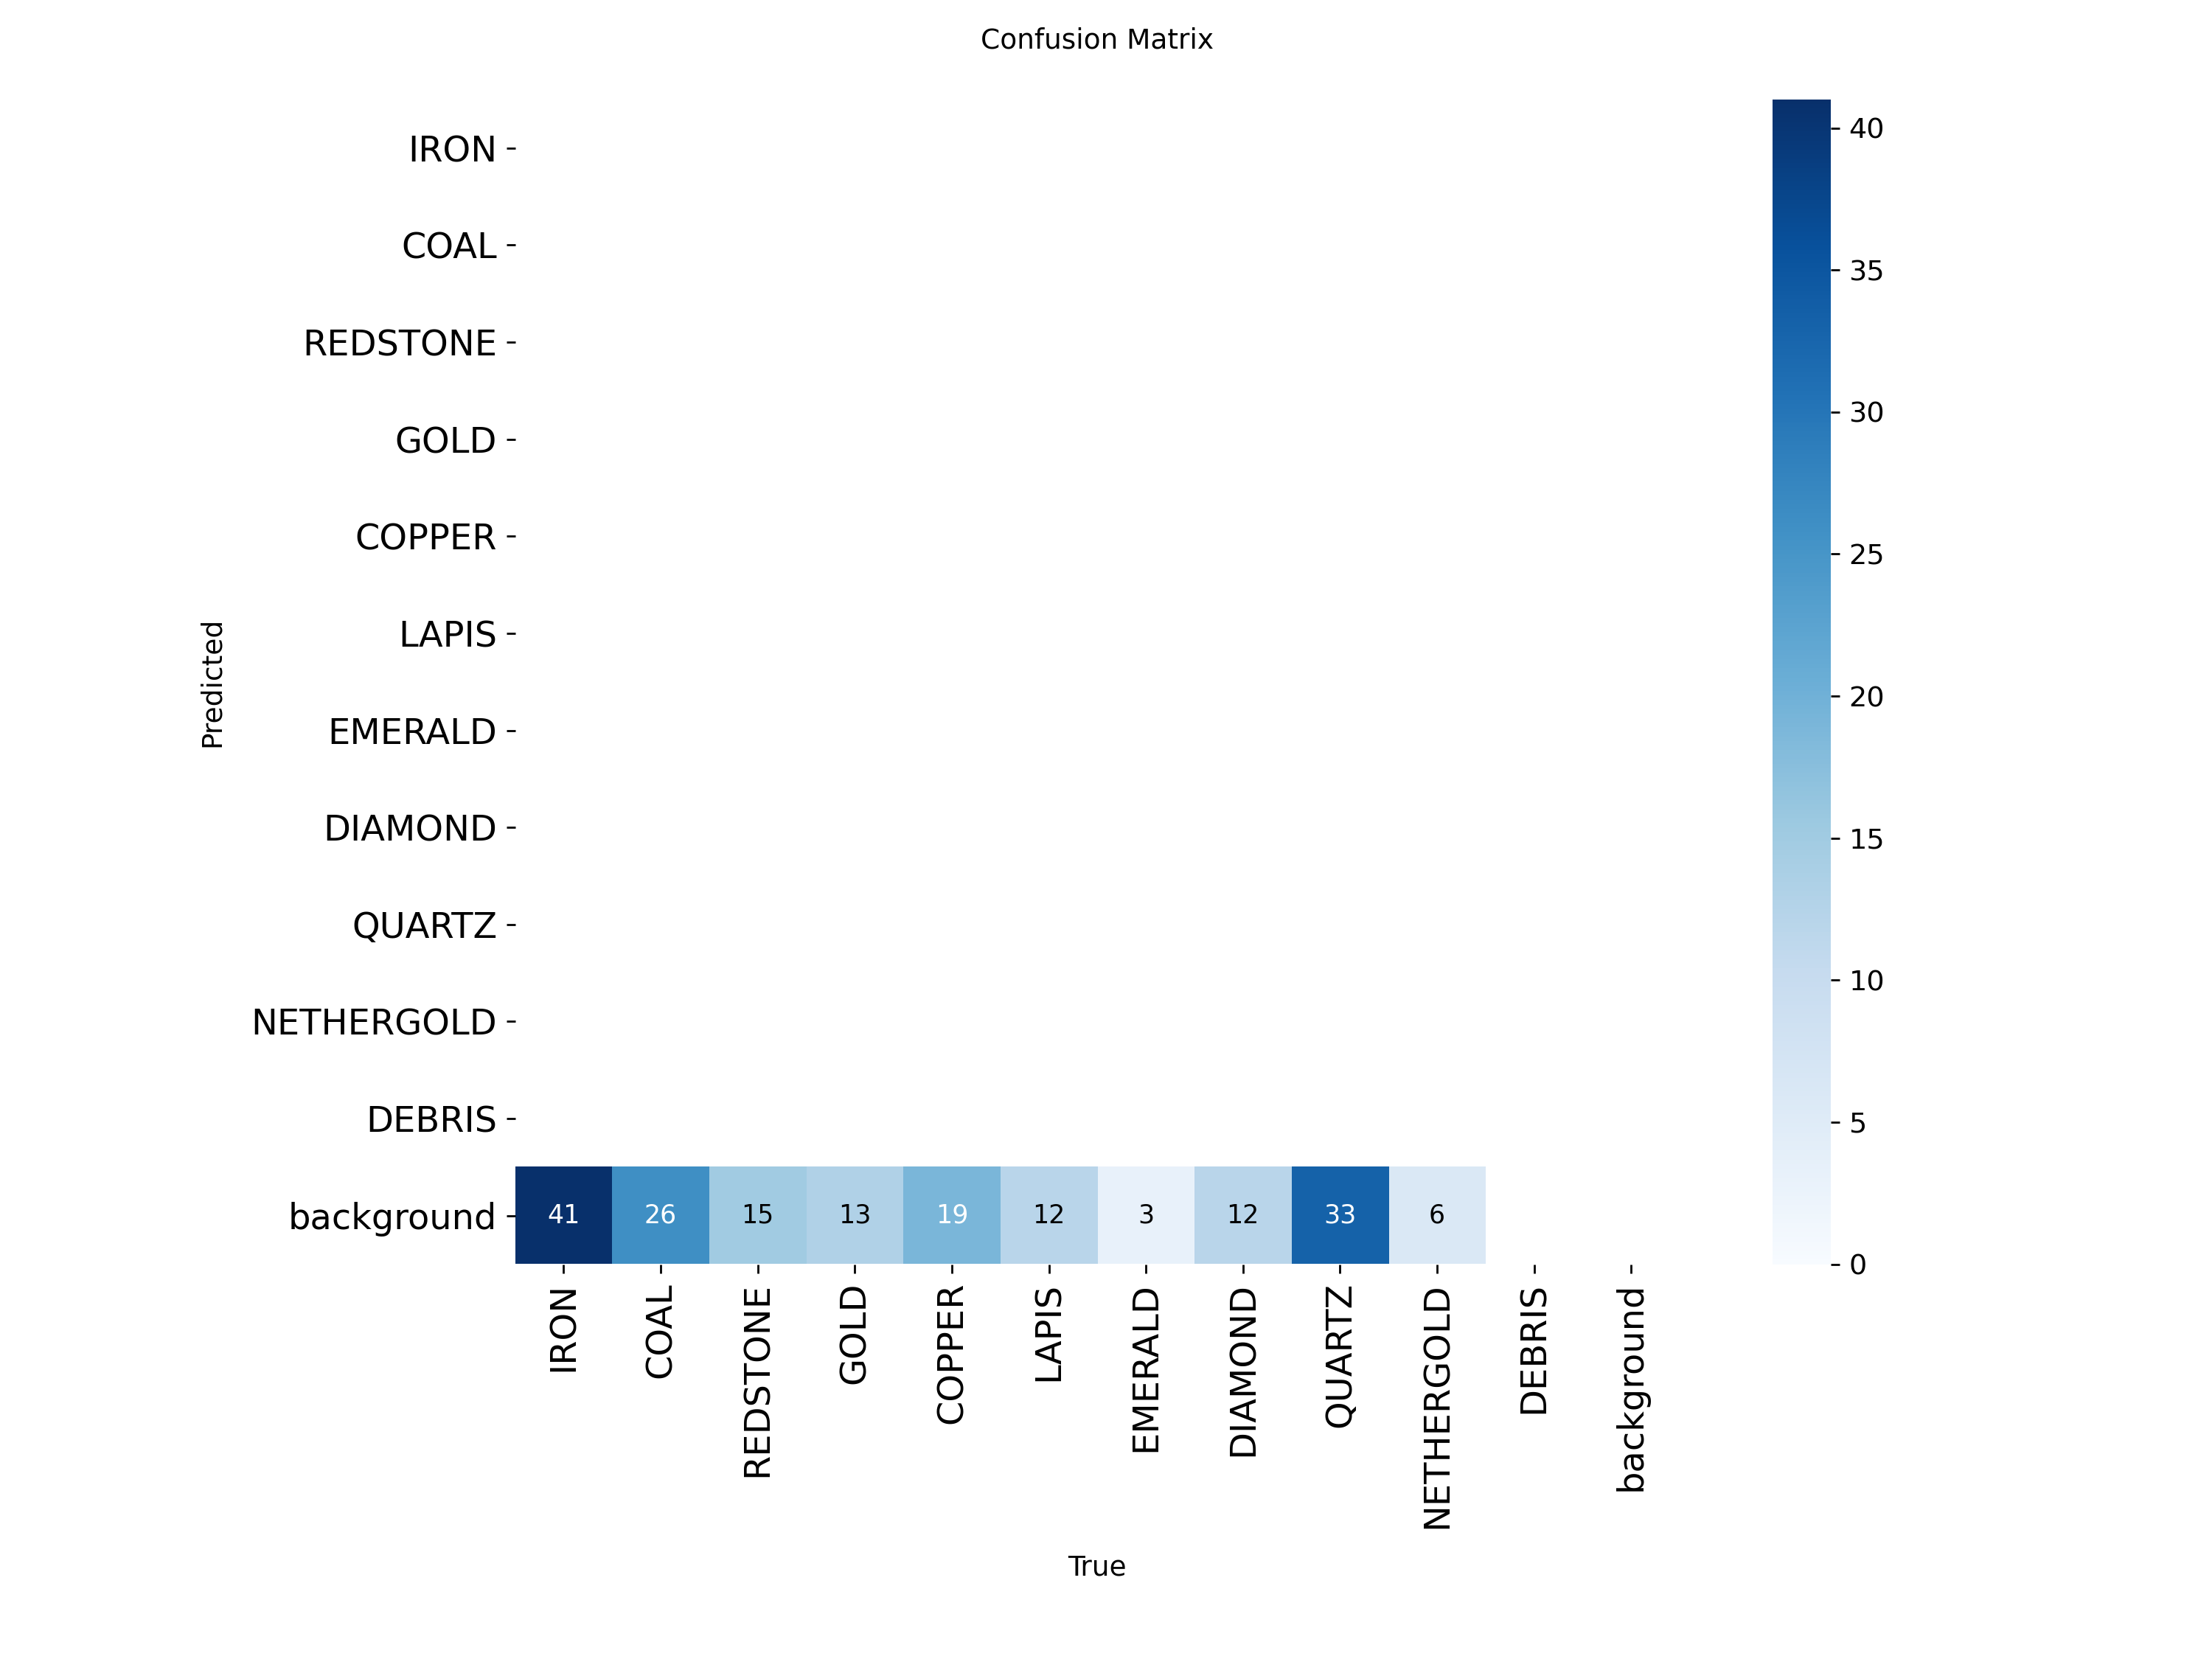

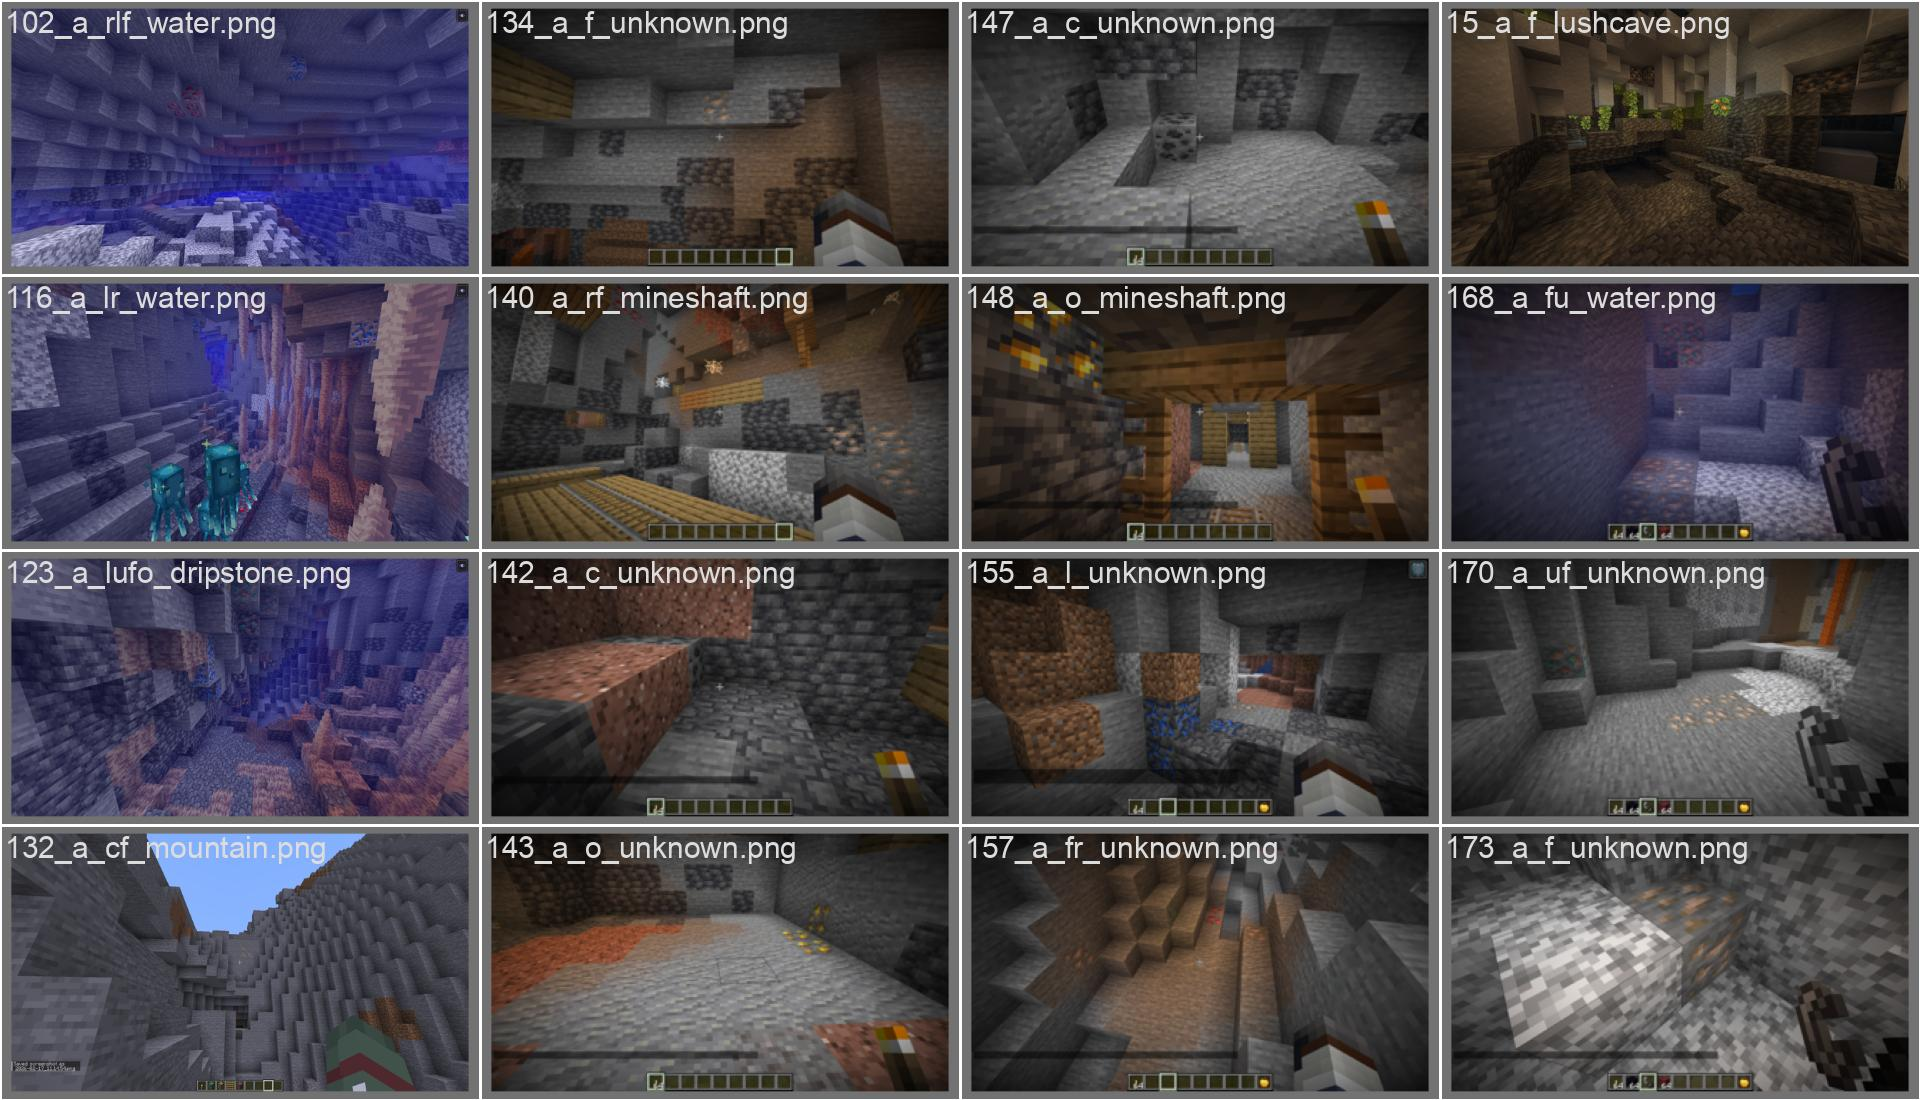

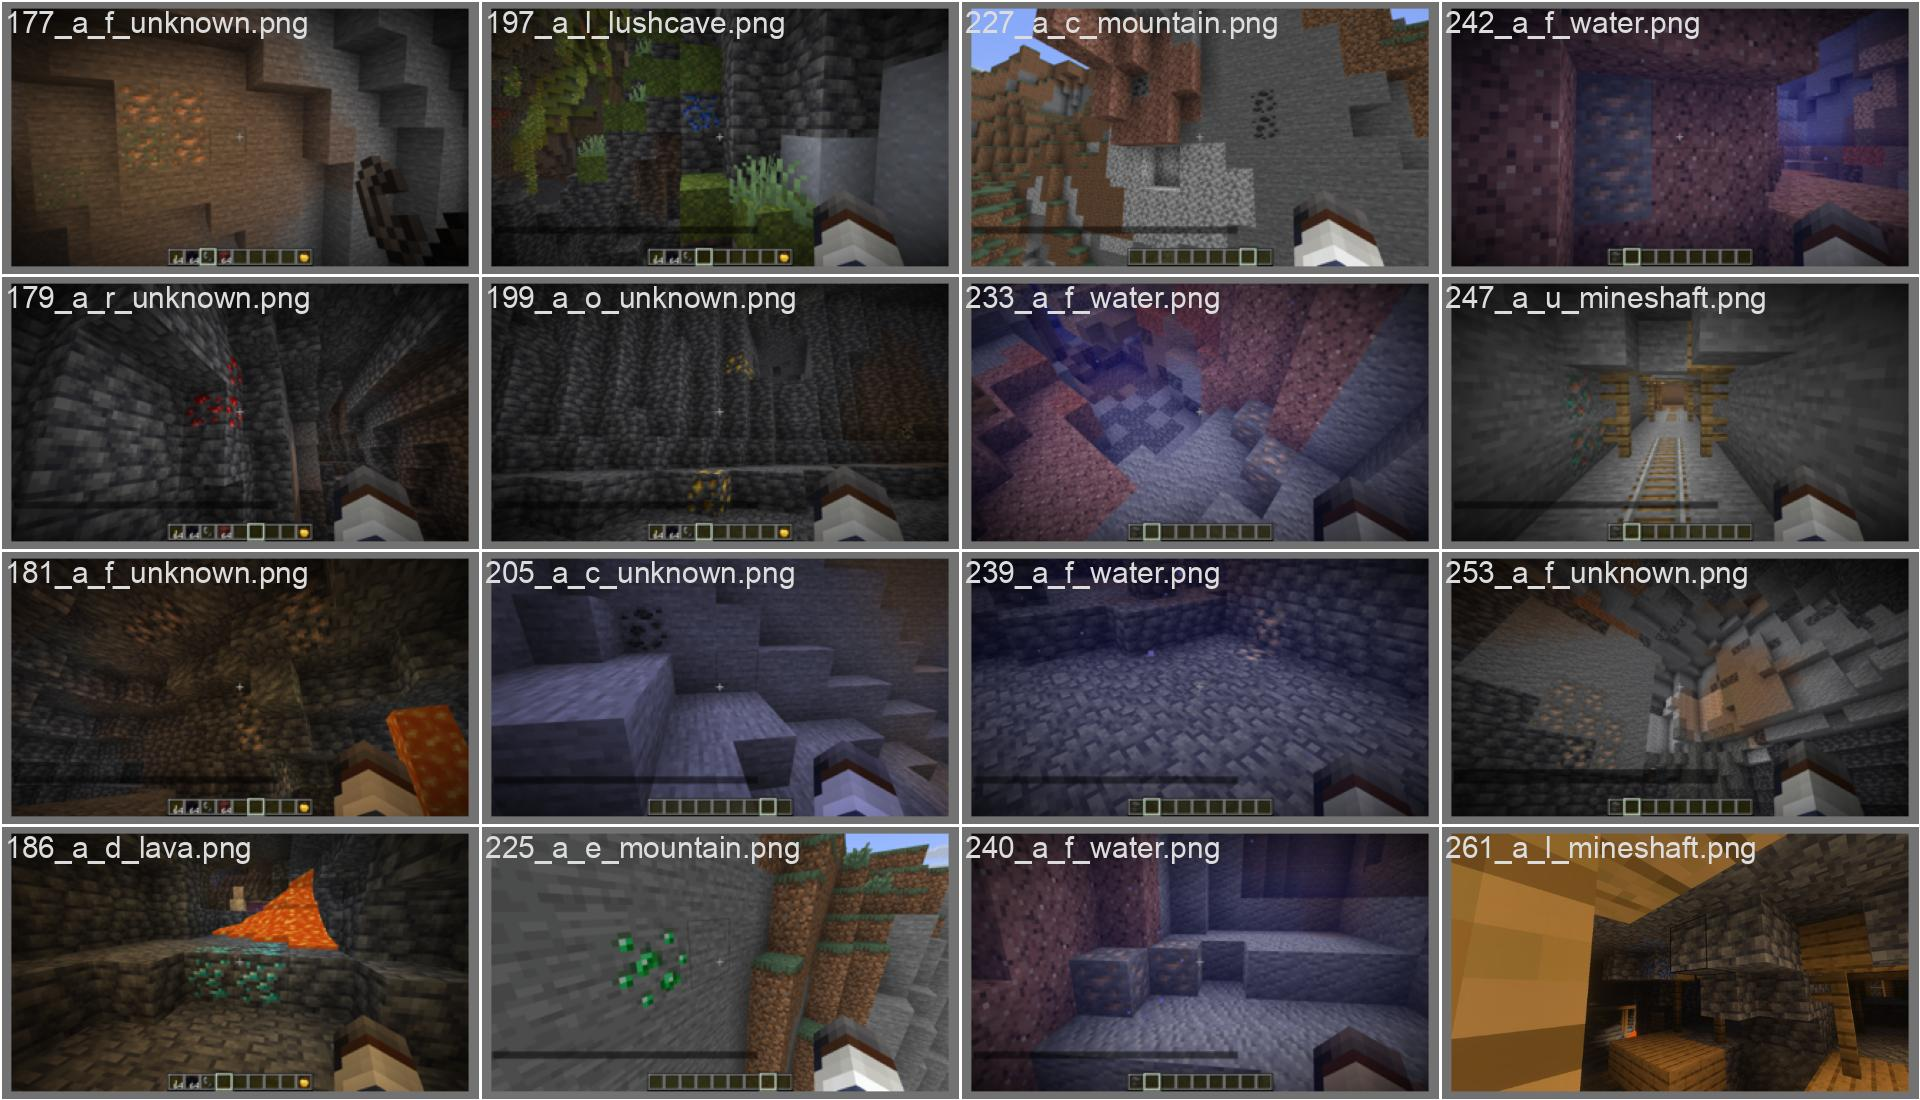

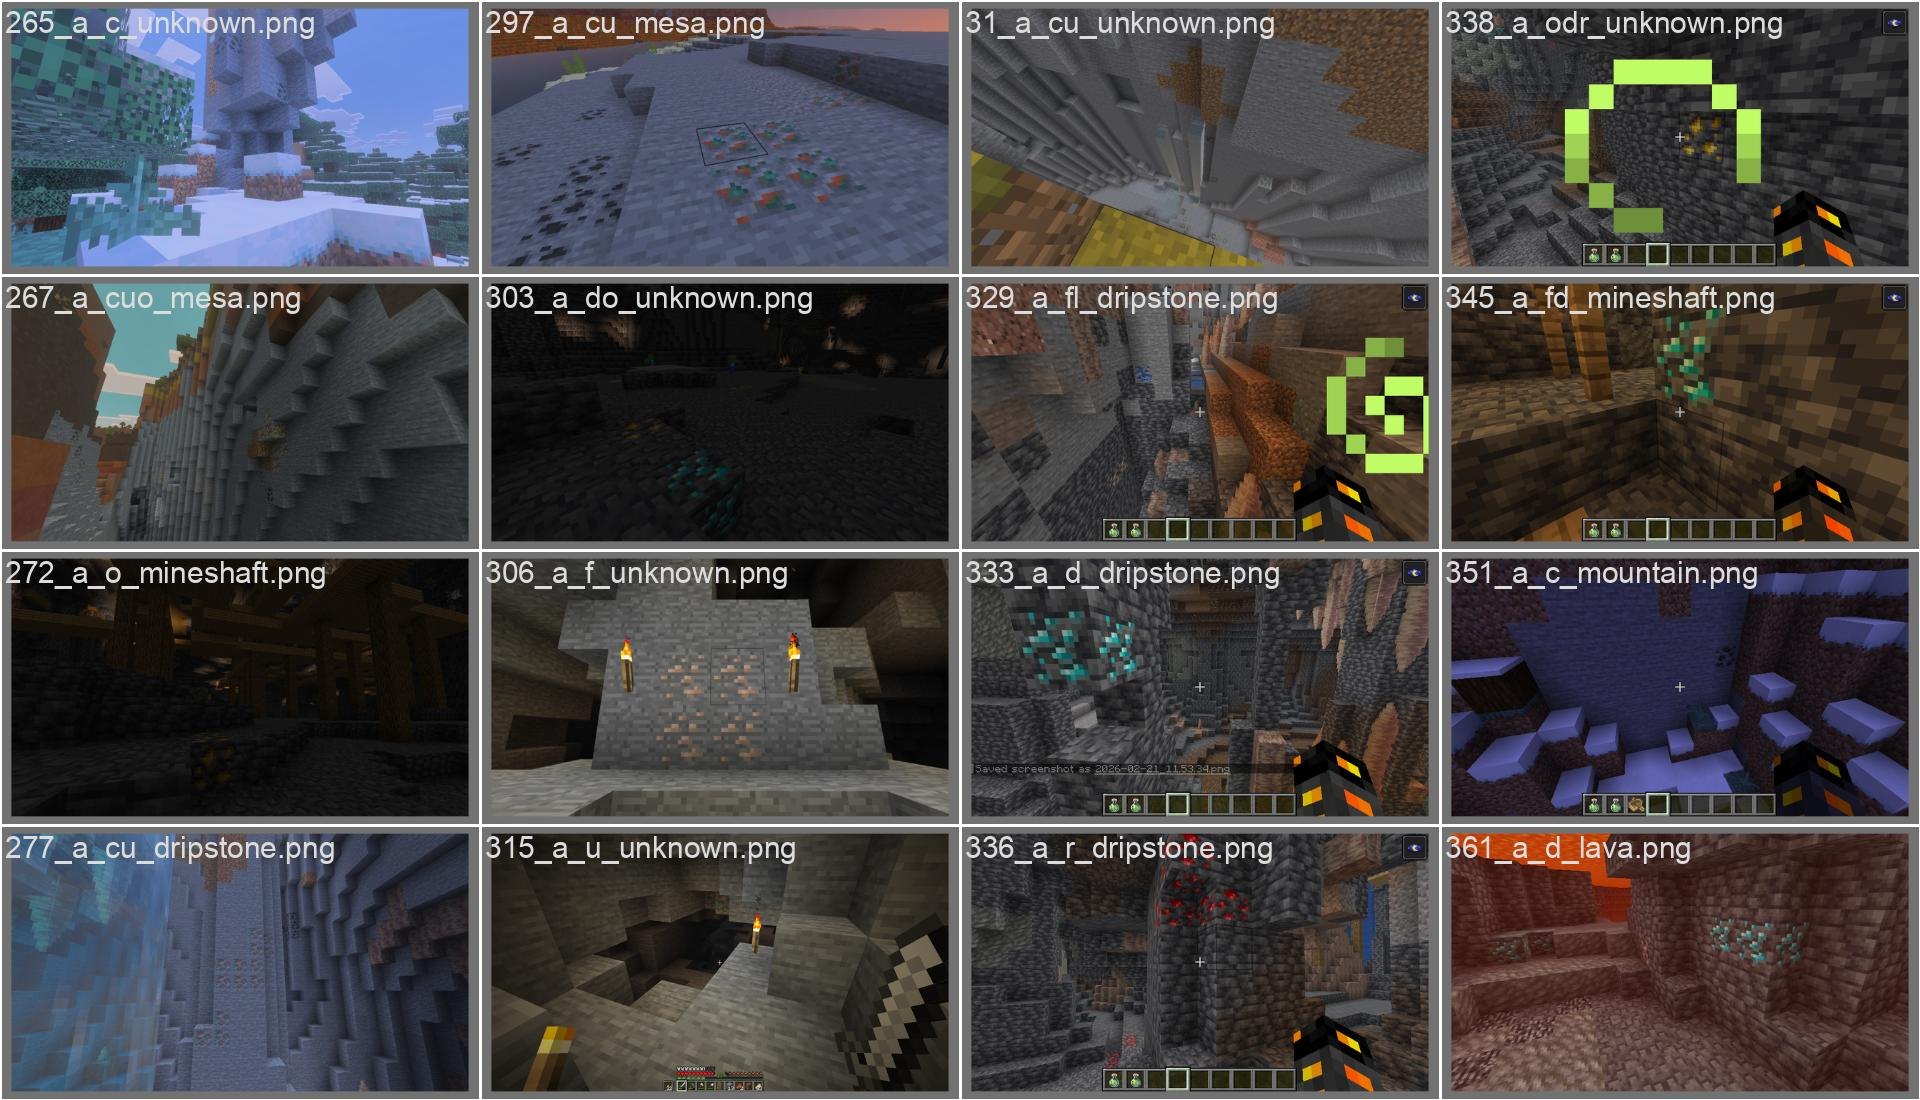

In [ ]:
from IPython.display import Image, display

#!ls runs/detect/train
#!ls runs/detect/val

display(Image(filename='runs/detect/train/results.png', width=800))
display(Image(filename='runs/detect/val/confusion_matrix.png', width=800))
display(Image(filename='runs/detect/val/val_batch0_pred.jpg', width=800))
display(Image(filename='runs/detect/val/val_batch1_pred.jpg', width=800))
display(Image(filename='runs/detect/val/val_batch2_pred.jpg', width=800))

In [ ]:
from google.colab import files

files.download('runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Analyse quantitative :

Etude de **Précision, Rappel, F1-score, mIOU**

CF https://www.ultralytics.com/fr/glossary/precision
et
https://scikit-learn.org/stable/modules/model_evaluation.html#string-name-scorers

Voir


- sklearn.metrics.precision_score ( https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score )


- sklearn.metrics.f1_score ( https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score )

- sklearn.metrics.accuracy_score ( https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score )


https://yolov8.org/what-is-map50-in-yolov8/

In [ ]:
# Validate the model on the COCO8 dataset to calculate metrics
#metrics = model.val(data="x-ray.yaml")

# Access and print the mean Precision (P) score
# The results dictionary contains keys for various metrics
#print(f"Mean Precision: {metrics.results_dict['metrics/precision(B)']:.4f}")

def analyse_resultat(results) :

  precision = results.results_dict['metrics/precision(B)']
  recall = results.results_dict['metrics/recall(B)']
  f1_score = 2/((1/precision)+(1/recall))

  print("Precision :",precision)
  print("Rappel :",recall)
  print("F1-Score :",f1_score)
  print(f"mAP@50-95: {results.box.map:.3f}")

  #print(results)
  #boxes = results[0].boxes
  #print(boxes)
  '''

  nb_val = nombre de val
  miou = 0
  for i in range(nb_val) :
    ground_truth = vérité terrain de l'image de val i                            torch.tensor([[100, 100, 200, 200]])
    predicted = prédiction de l'image de val i                                   torch.tensor([[110, 110, 210, 210]])

    Calculate the Intersection over Union score
    iou_score = box_iou(ground_truth, predicted)
    miou = miou + iou_score
  miou = miou / nb_val
  '''

analyse_resultat(results)

Precision : 0.6350197804019014
Rappel : 0.5194151824019071
F1-Score : 0.571429185175029
mAP@50-95: 0.381


# Augmentation des données :  

https://docs.ultralytics.com/guides/yolo-data-augmentation/#example-configurations

https://docs.ultralytics.com/reference/data/augment

https://docs.ultralytics.com/modes/val

https://docs.ultralytics.com/modes/train

Le modèle d'ultralytics nous permet d'augmenter les données en effectuant des transformations sur les images. Nous avons adapté les transformations à notre problème :


*   translate, scale, flip, mosaic ...
*   les transformations sur les couleurs ne sont pas adaptées.




In [ ]:
!rm -fr runs

# Load a pretrained YOLO model (recommended for training)
model = YOLO("yolo26n.pt")

# Train the model using the 'x-ray.yaml' dataset for 100 epochs
results = model.train(
      data="x-ray/dataset/x-ray.yaml",
      epochs=100,
      degrees=180,
      translate=1, # Déplacer l'image
      scale=1, # Changement de la taille
      shear=10, # Inclinaison
      perspective=0.001, # Inclinaison
      flipud=1, # Tourner
      fliplr=1, # Tourner
      mosaic=1, # une mozaique des images
      cutmix=1, # une mozaique bizarre
      save_json=True,
      auto_augment=None)

# Evaluate the model's performance on the validation set
results = model.val(save_json=True)

'''
# Perform object detection on an image using the model
results = model("https://ultralytics.com/images/bus.jpg")

# Export the model to ONNX formatf
success = model.export(format="onnx")
'''

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=1, data=x-ray/dataset/x-ray.yaml, degrees=180, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=1, flipud=1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.001,

In [ ]:
from google.colab import files

files.download('runs/detect/train/weights/best.pt')

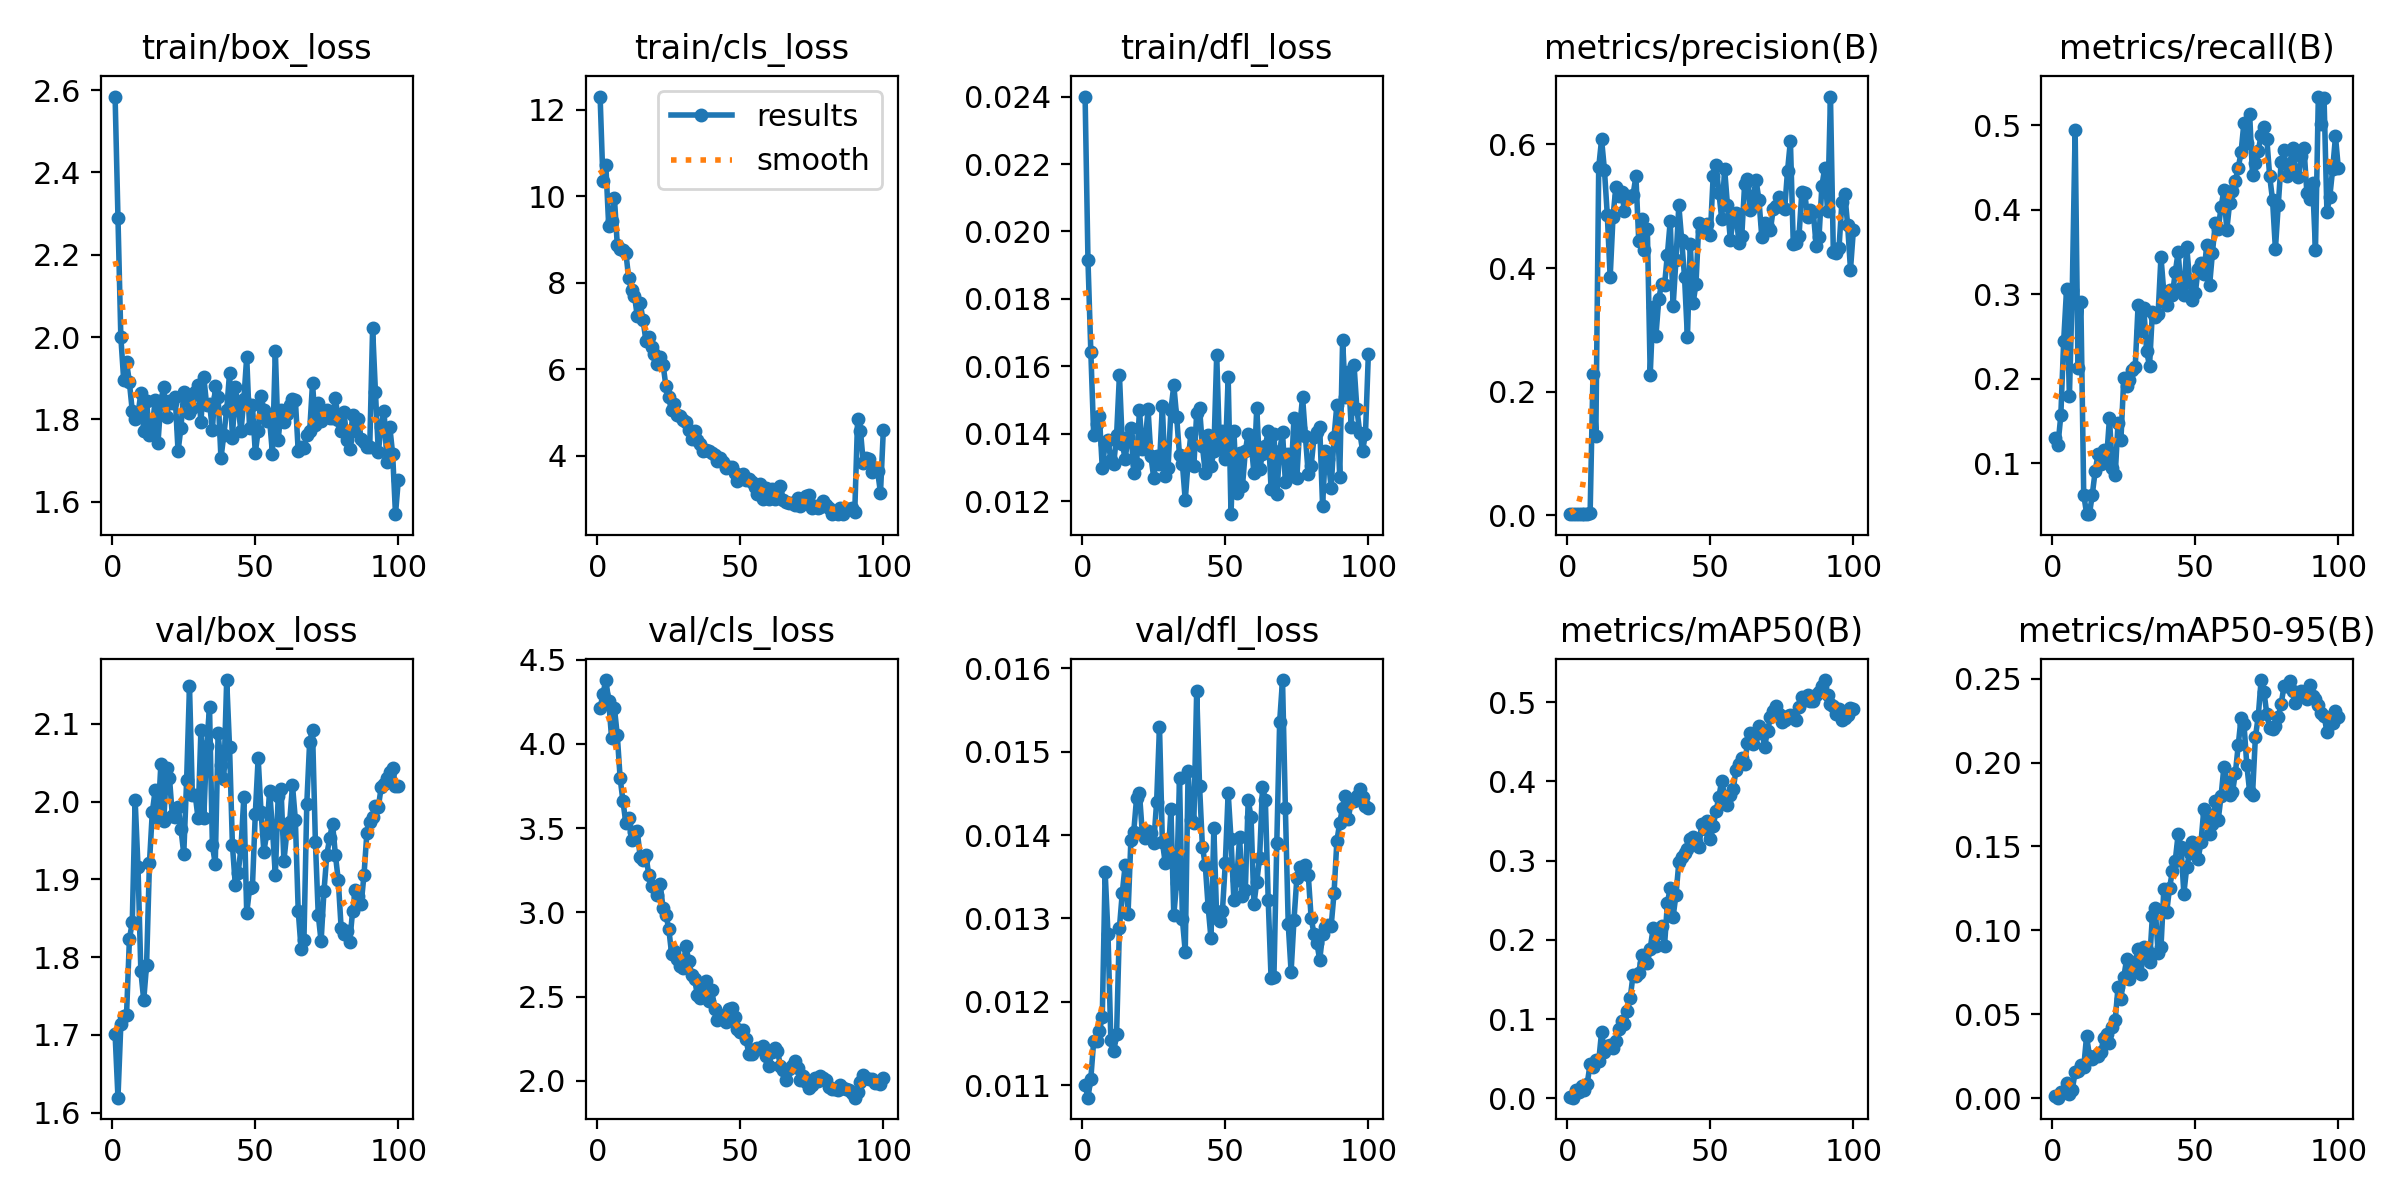

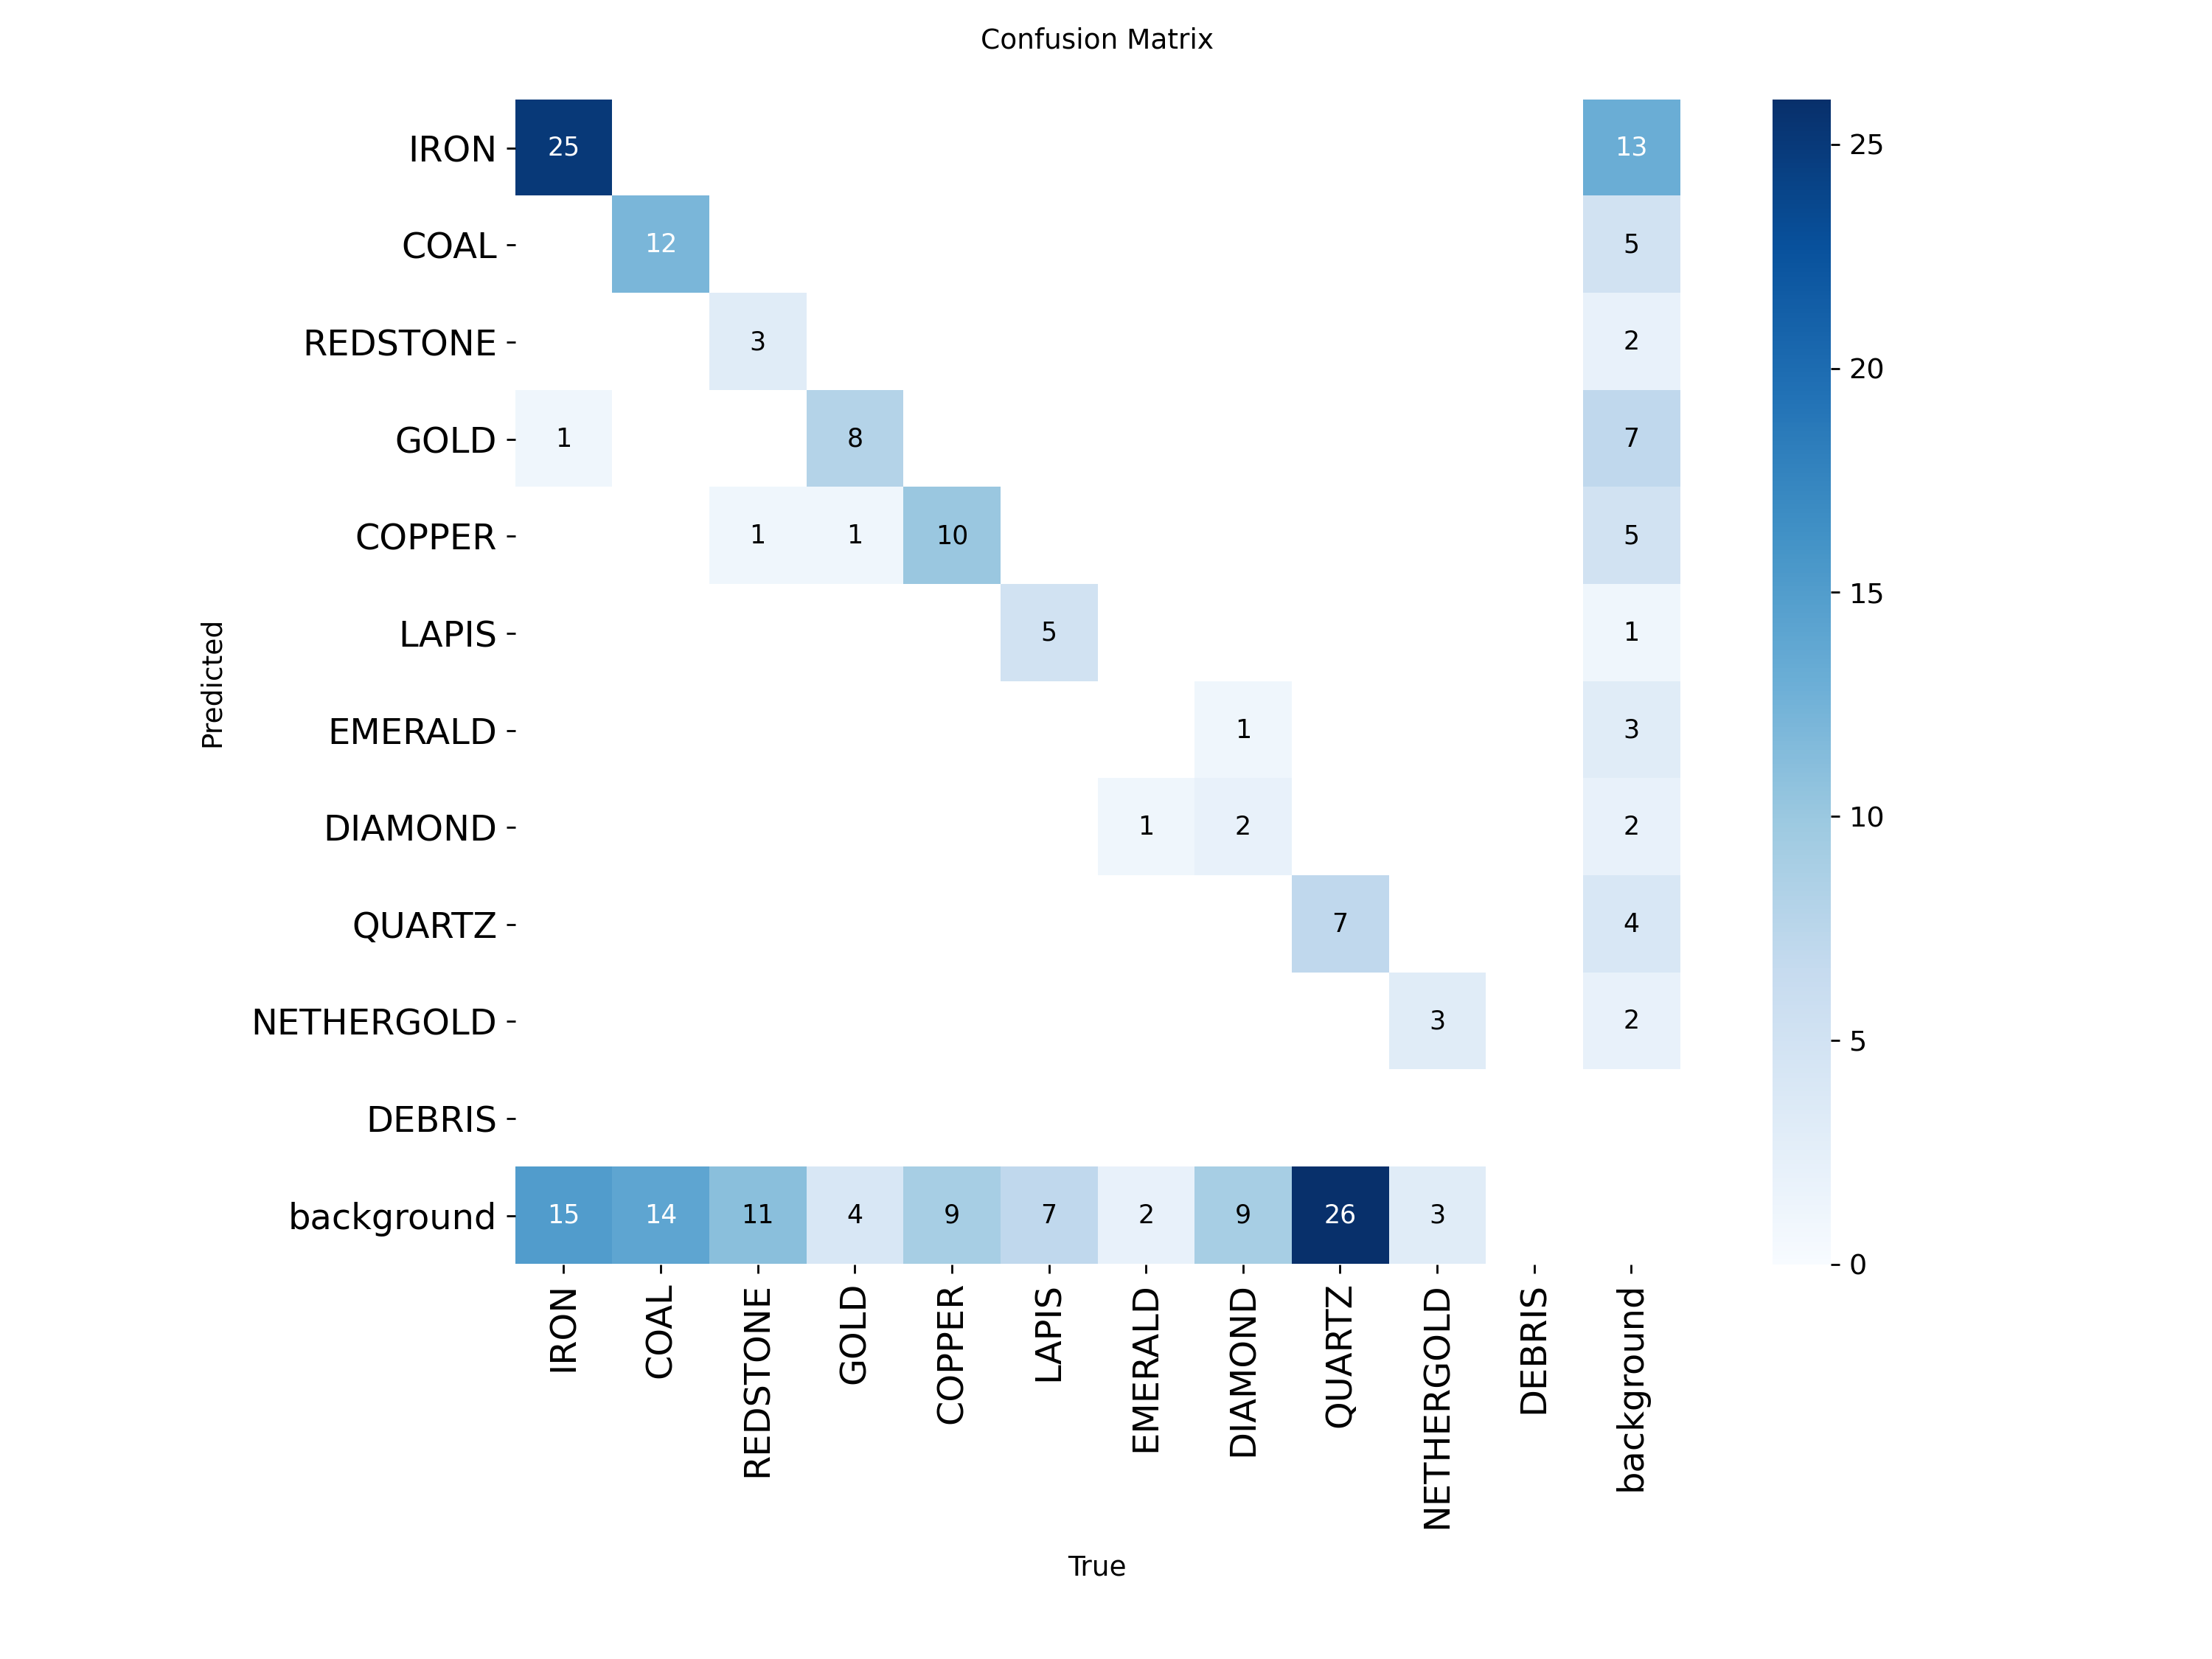

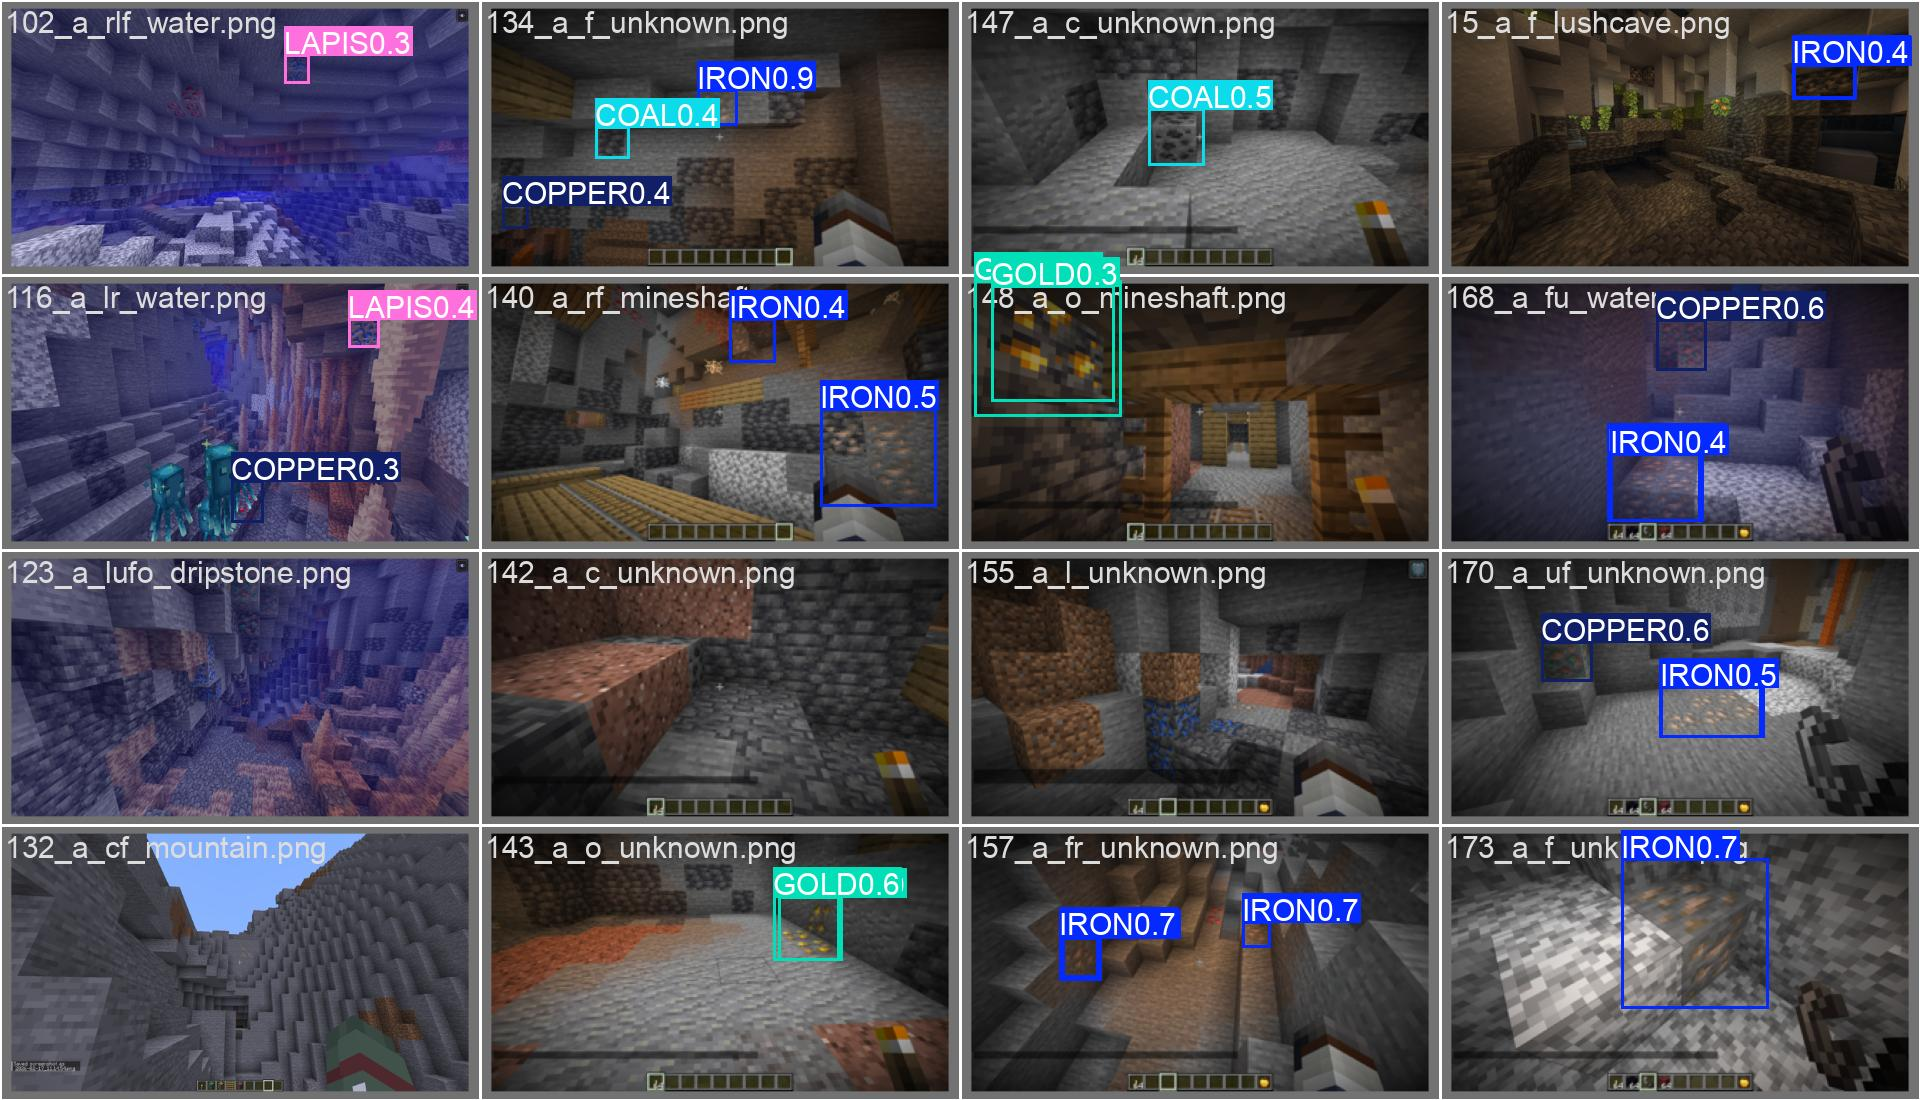

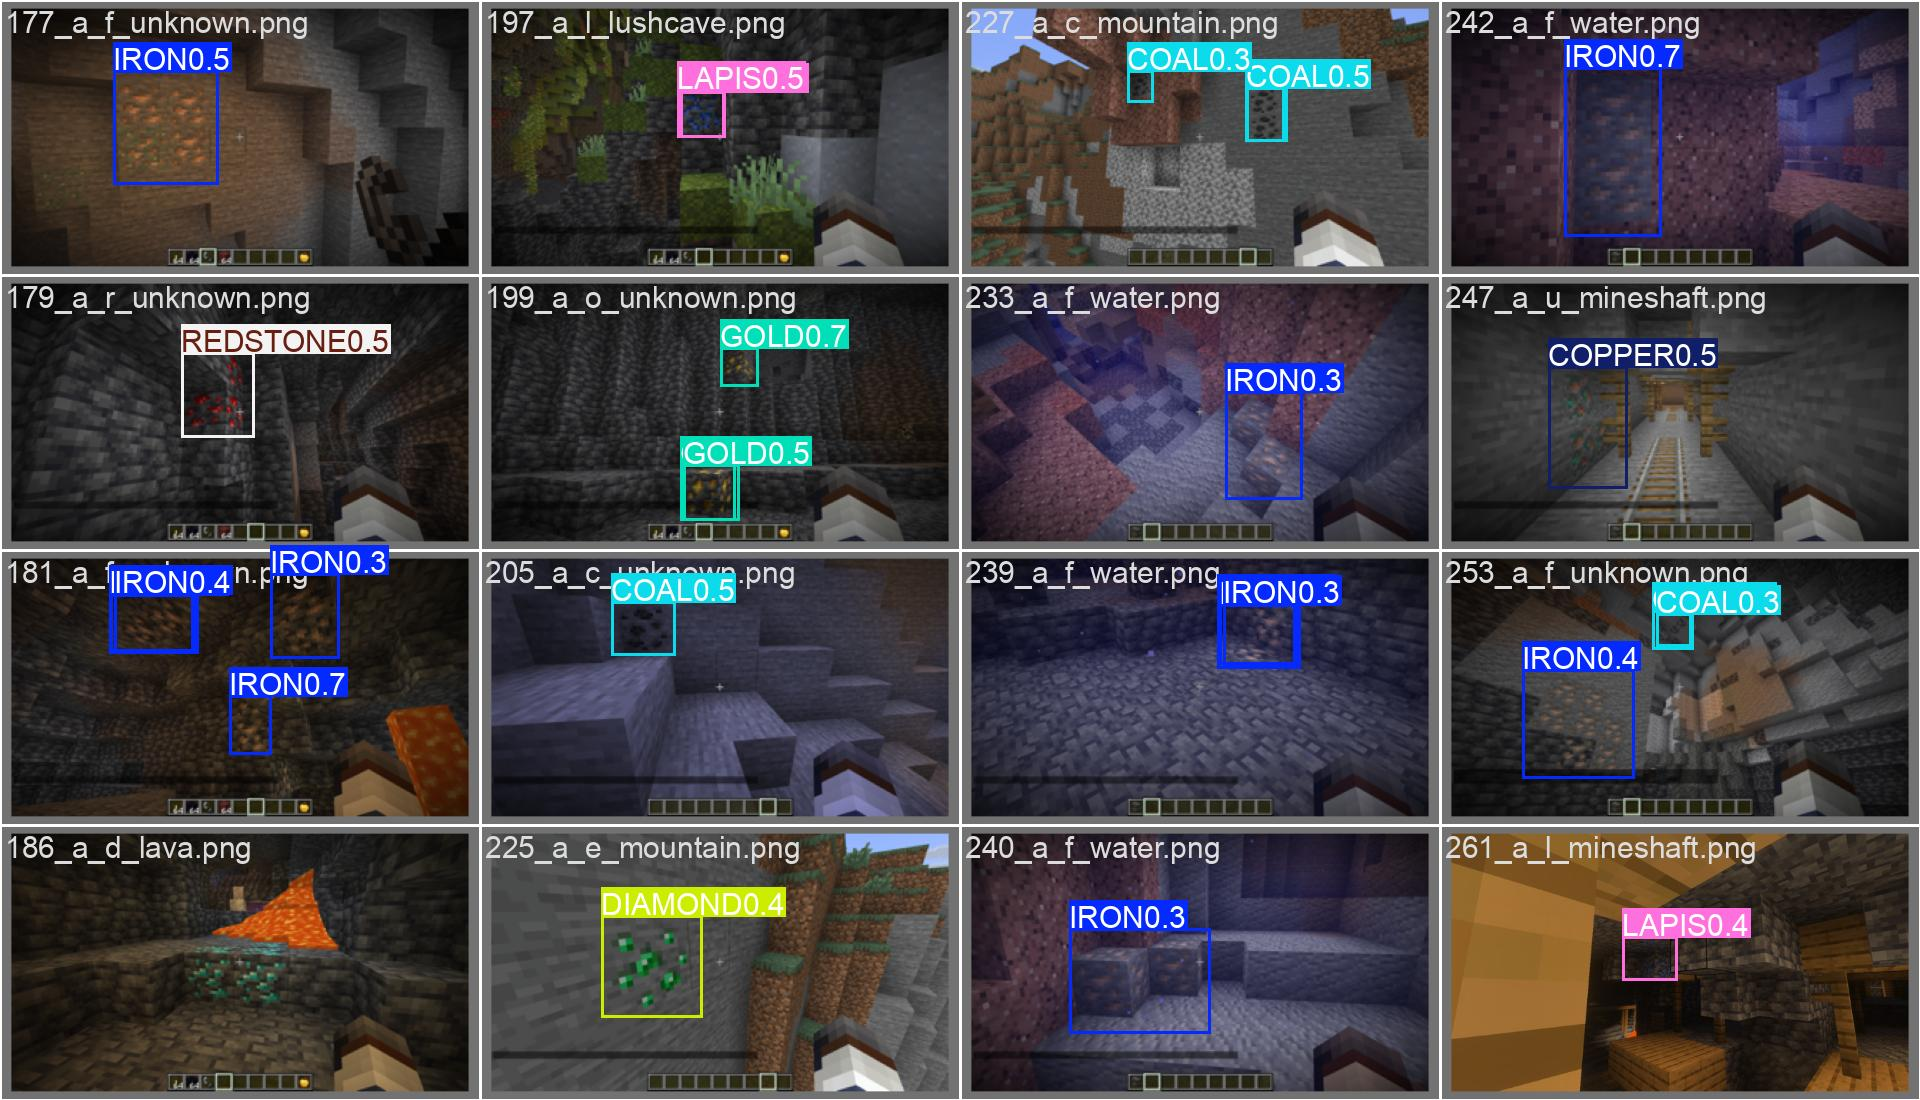

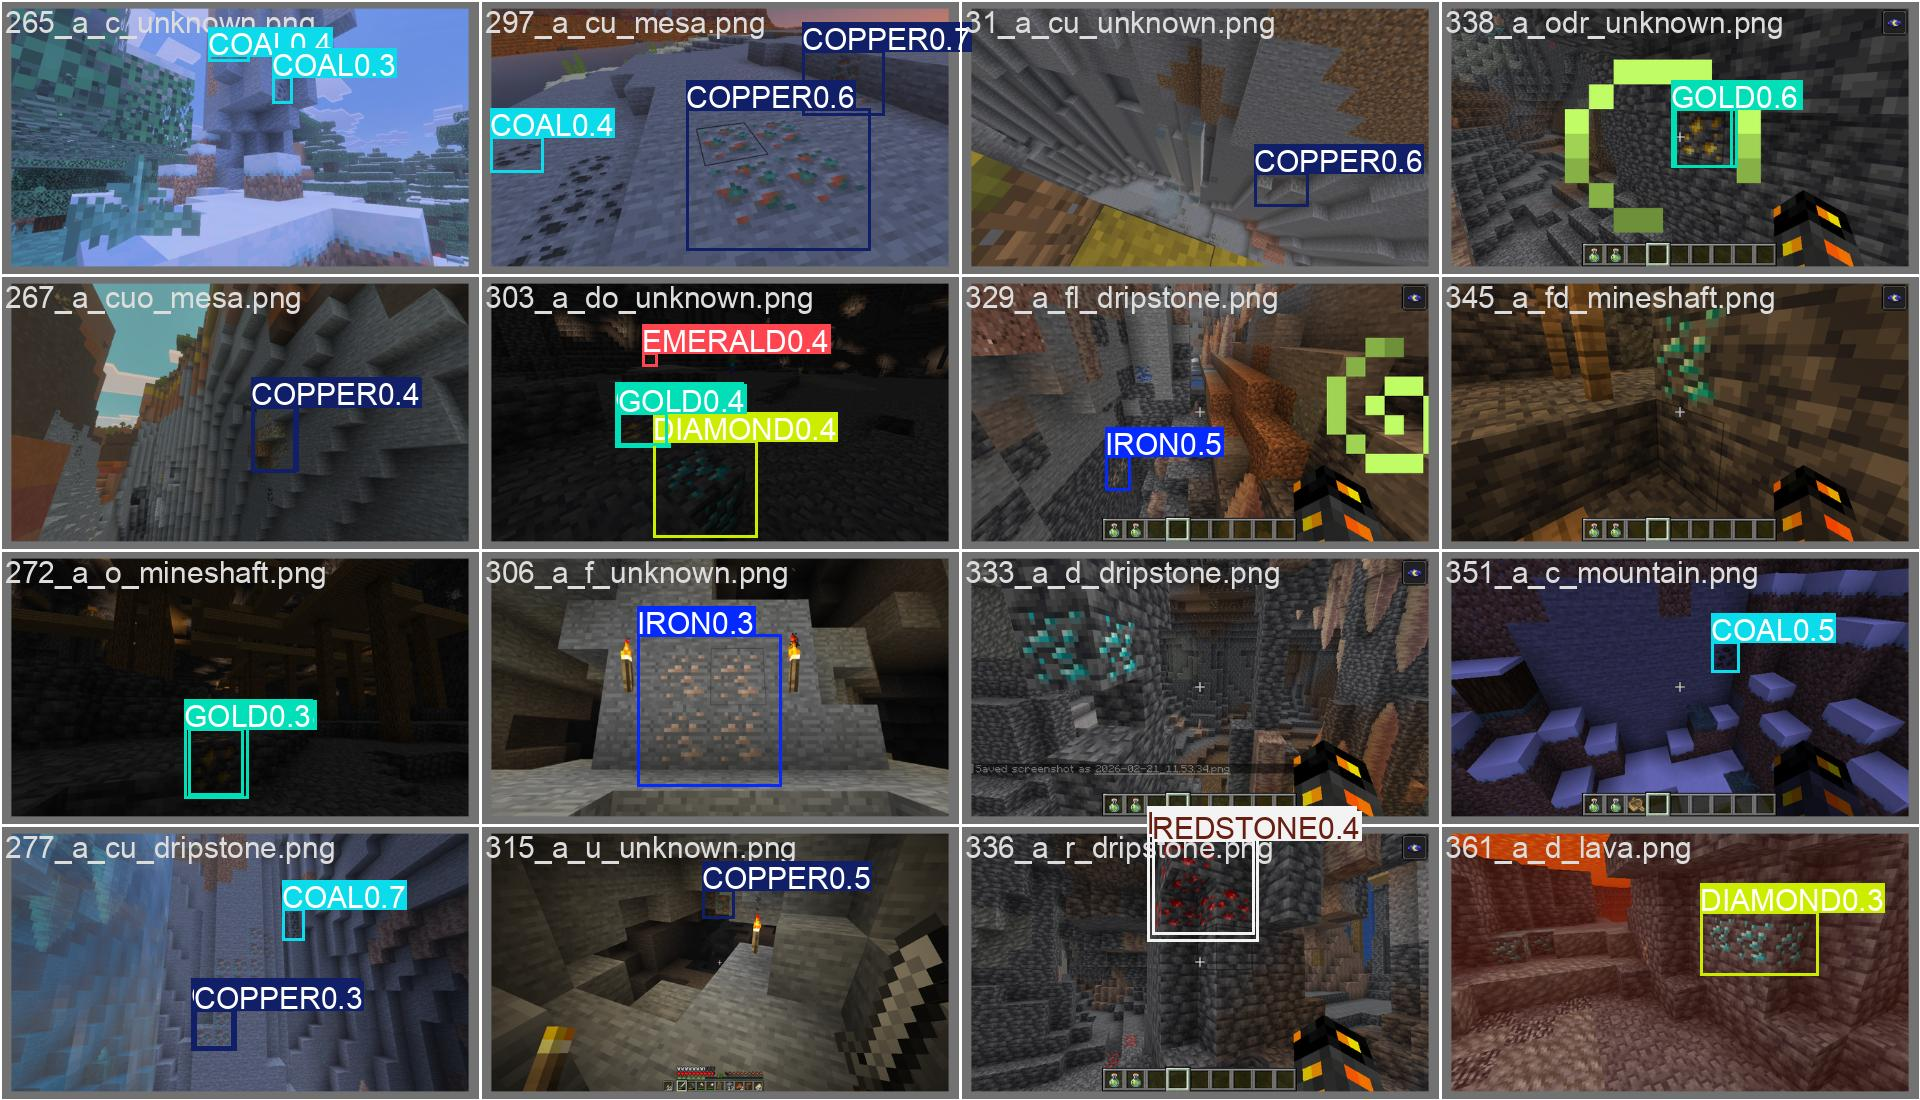

In [ ]:
from IPython.display import Image, display

#!ls runs/detect/train
#!ls runs/detect/val

display(Image(filename='runs/detect/train/results.png', width=800))
display(Image(filename='runs/detect/val/confusion_matrix.png', width=800))
display(Image(filename='runs/detect/val/val_batch0_pred.jpg', width=800))
display(Image(filename='runs/detect/val/val_batch1_pred.jpg', width=800))
display(Image(filename='runs/detect/val/val_batch2_pred.jpg', width=800))

# Augmentation de données automatique


In [ ]:
!rm -fr runs

# Load a pretrained YOLO model (recommended for training)
model = YOLO("yolo26n.pt")

# Train the model using the 'x-ray.yaml' dataset for 100 epochs
results = model.train(data="x-ray/dataset/x-ray.yaml", epochs=100, save_json=True)

# Evaluate the model's performance on the validation set
results = model.val()

'''
# Perform object detection on an image using the model
results = model("https://ultralytics.com/images/bus.jpg")

# Export the model to ONNX formatf
success = model.export(format="onnx")
'''

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=x-ray/dataset/x-ray.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

'\n# Perform object detection on an image using the model\nresults = model("https://ultralytics.com/images/bus.jpg")\n\n# Export the model to ONNX formatf\nsuccess = model.export(format="onnx")\n'

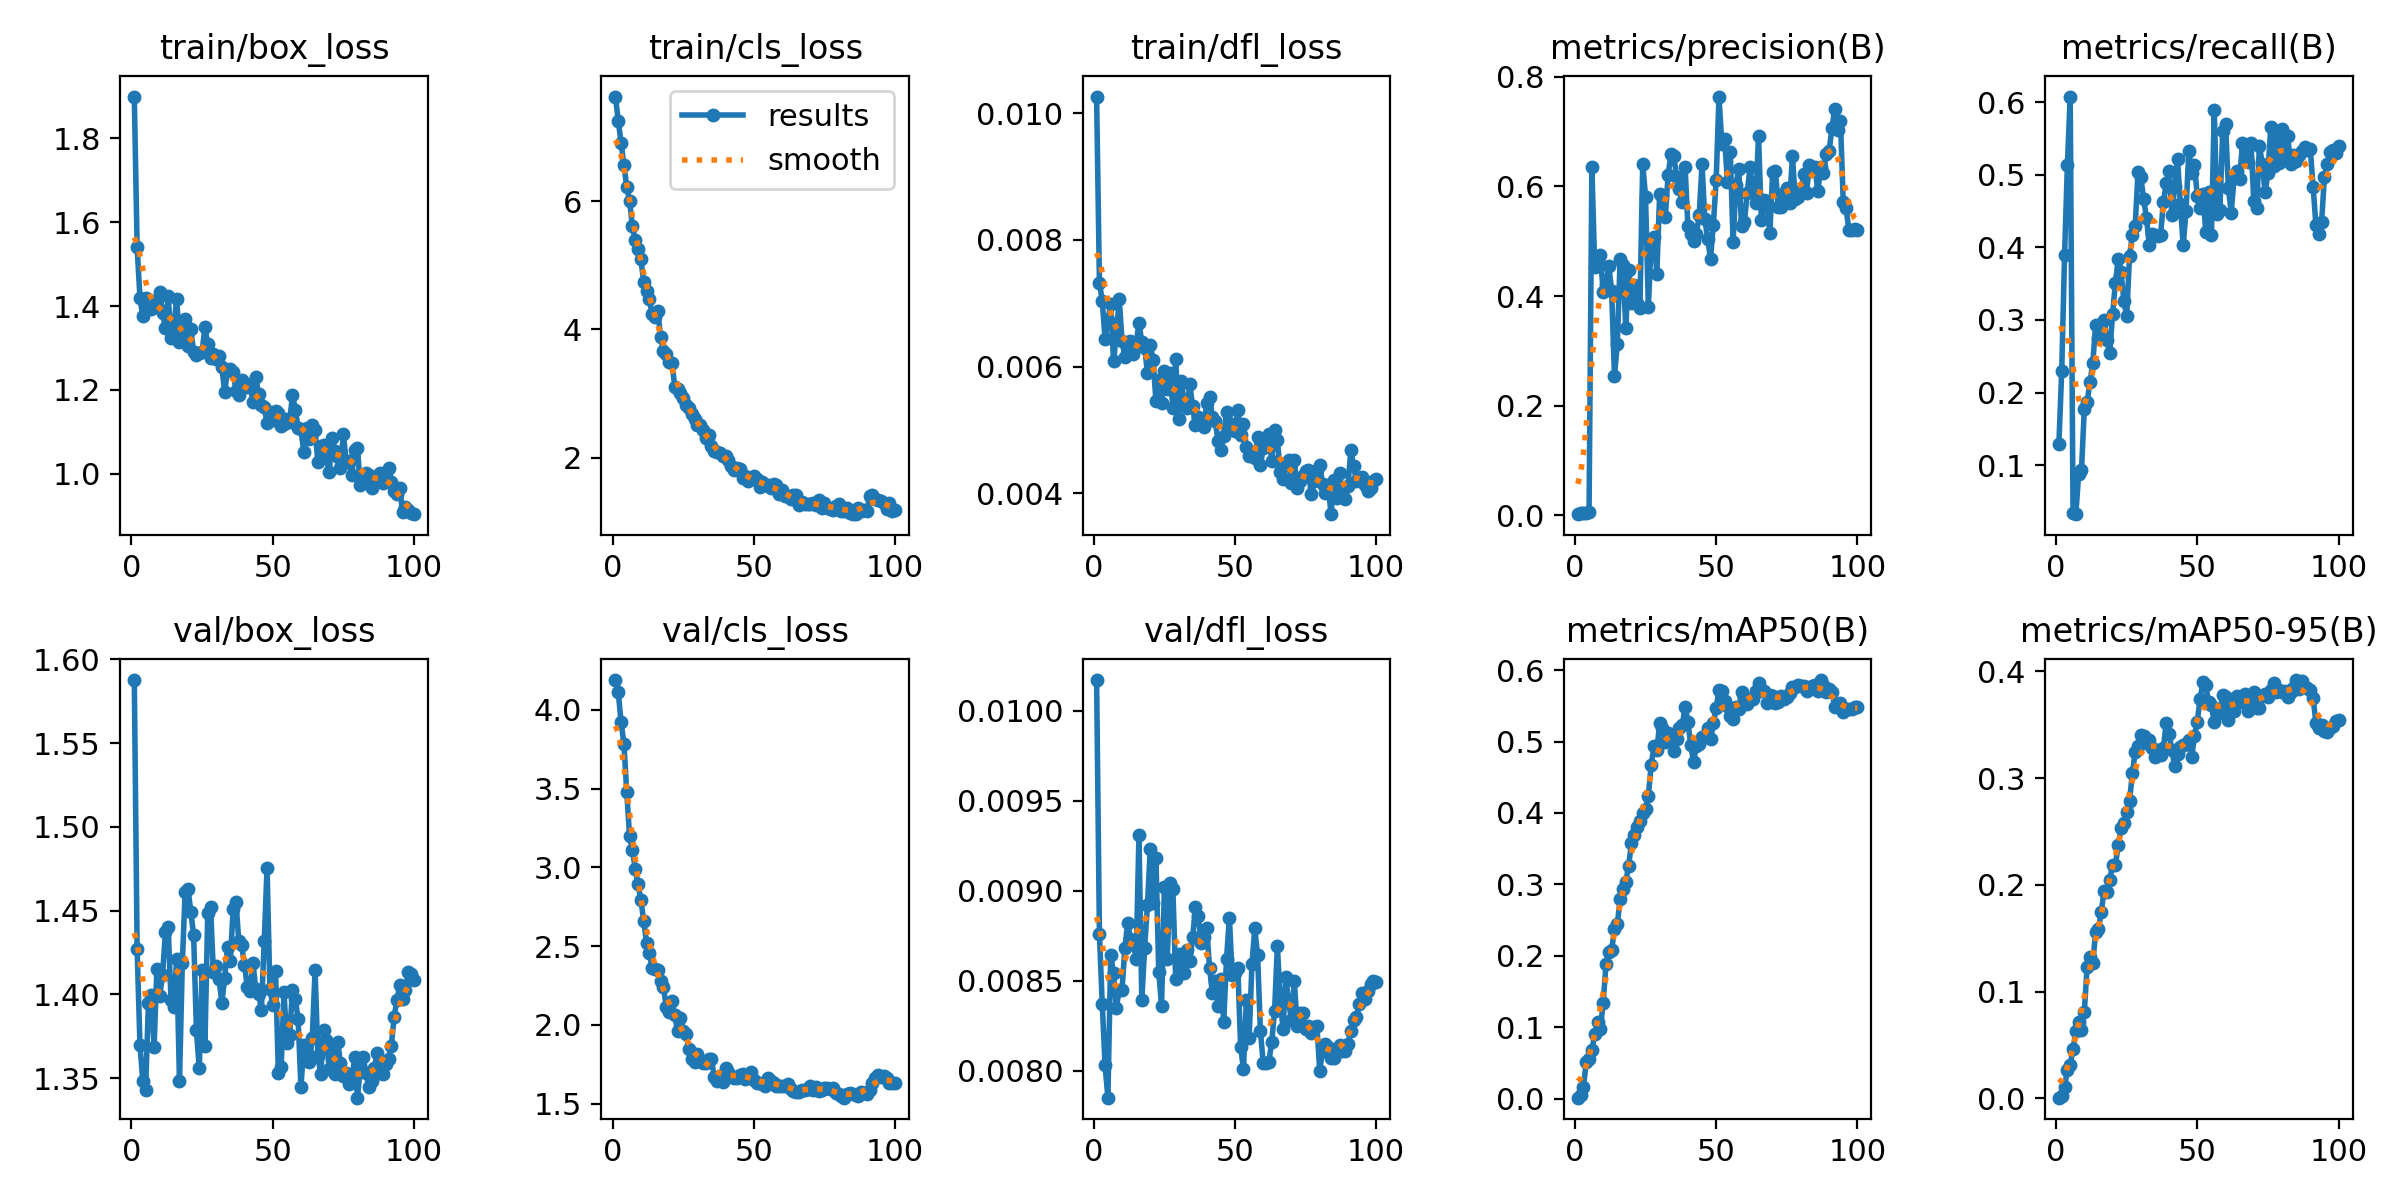

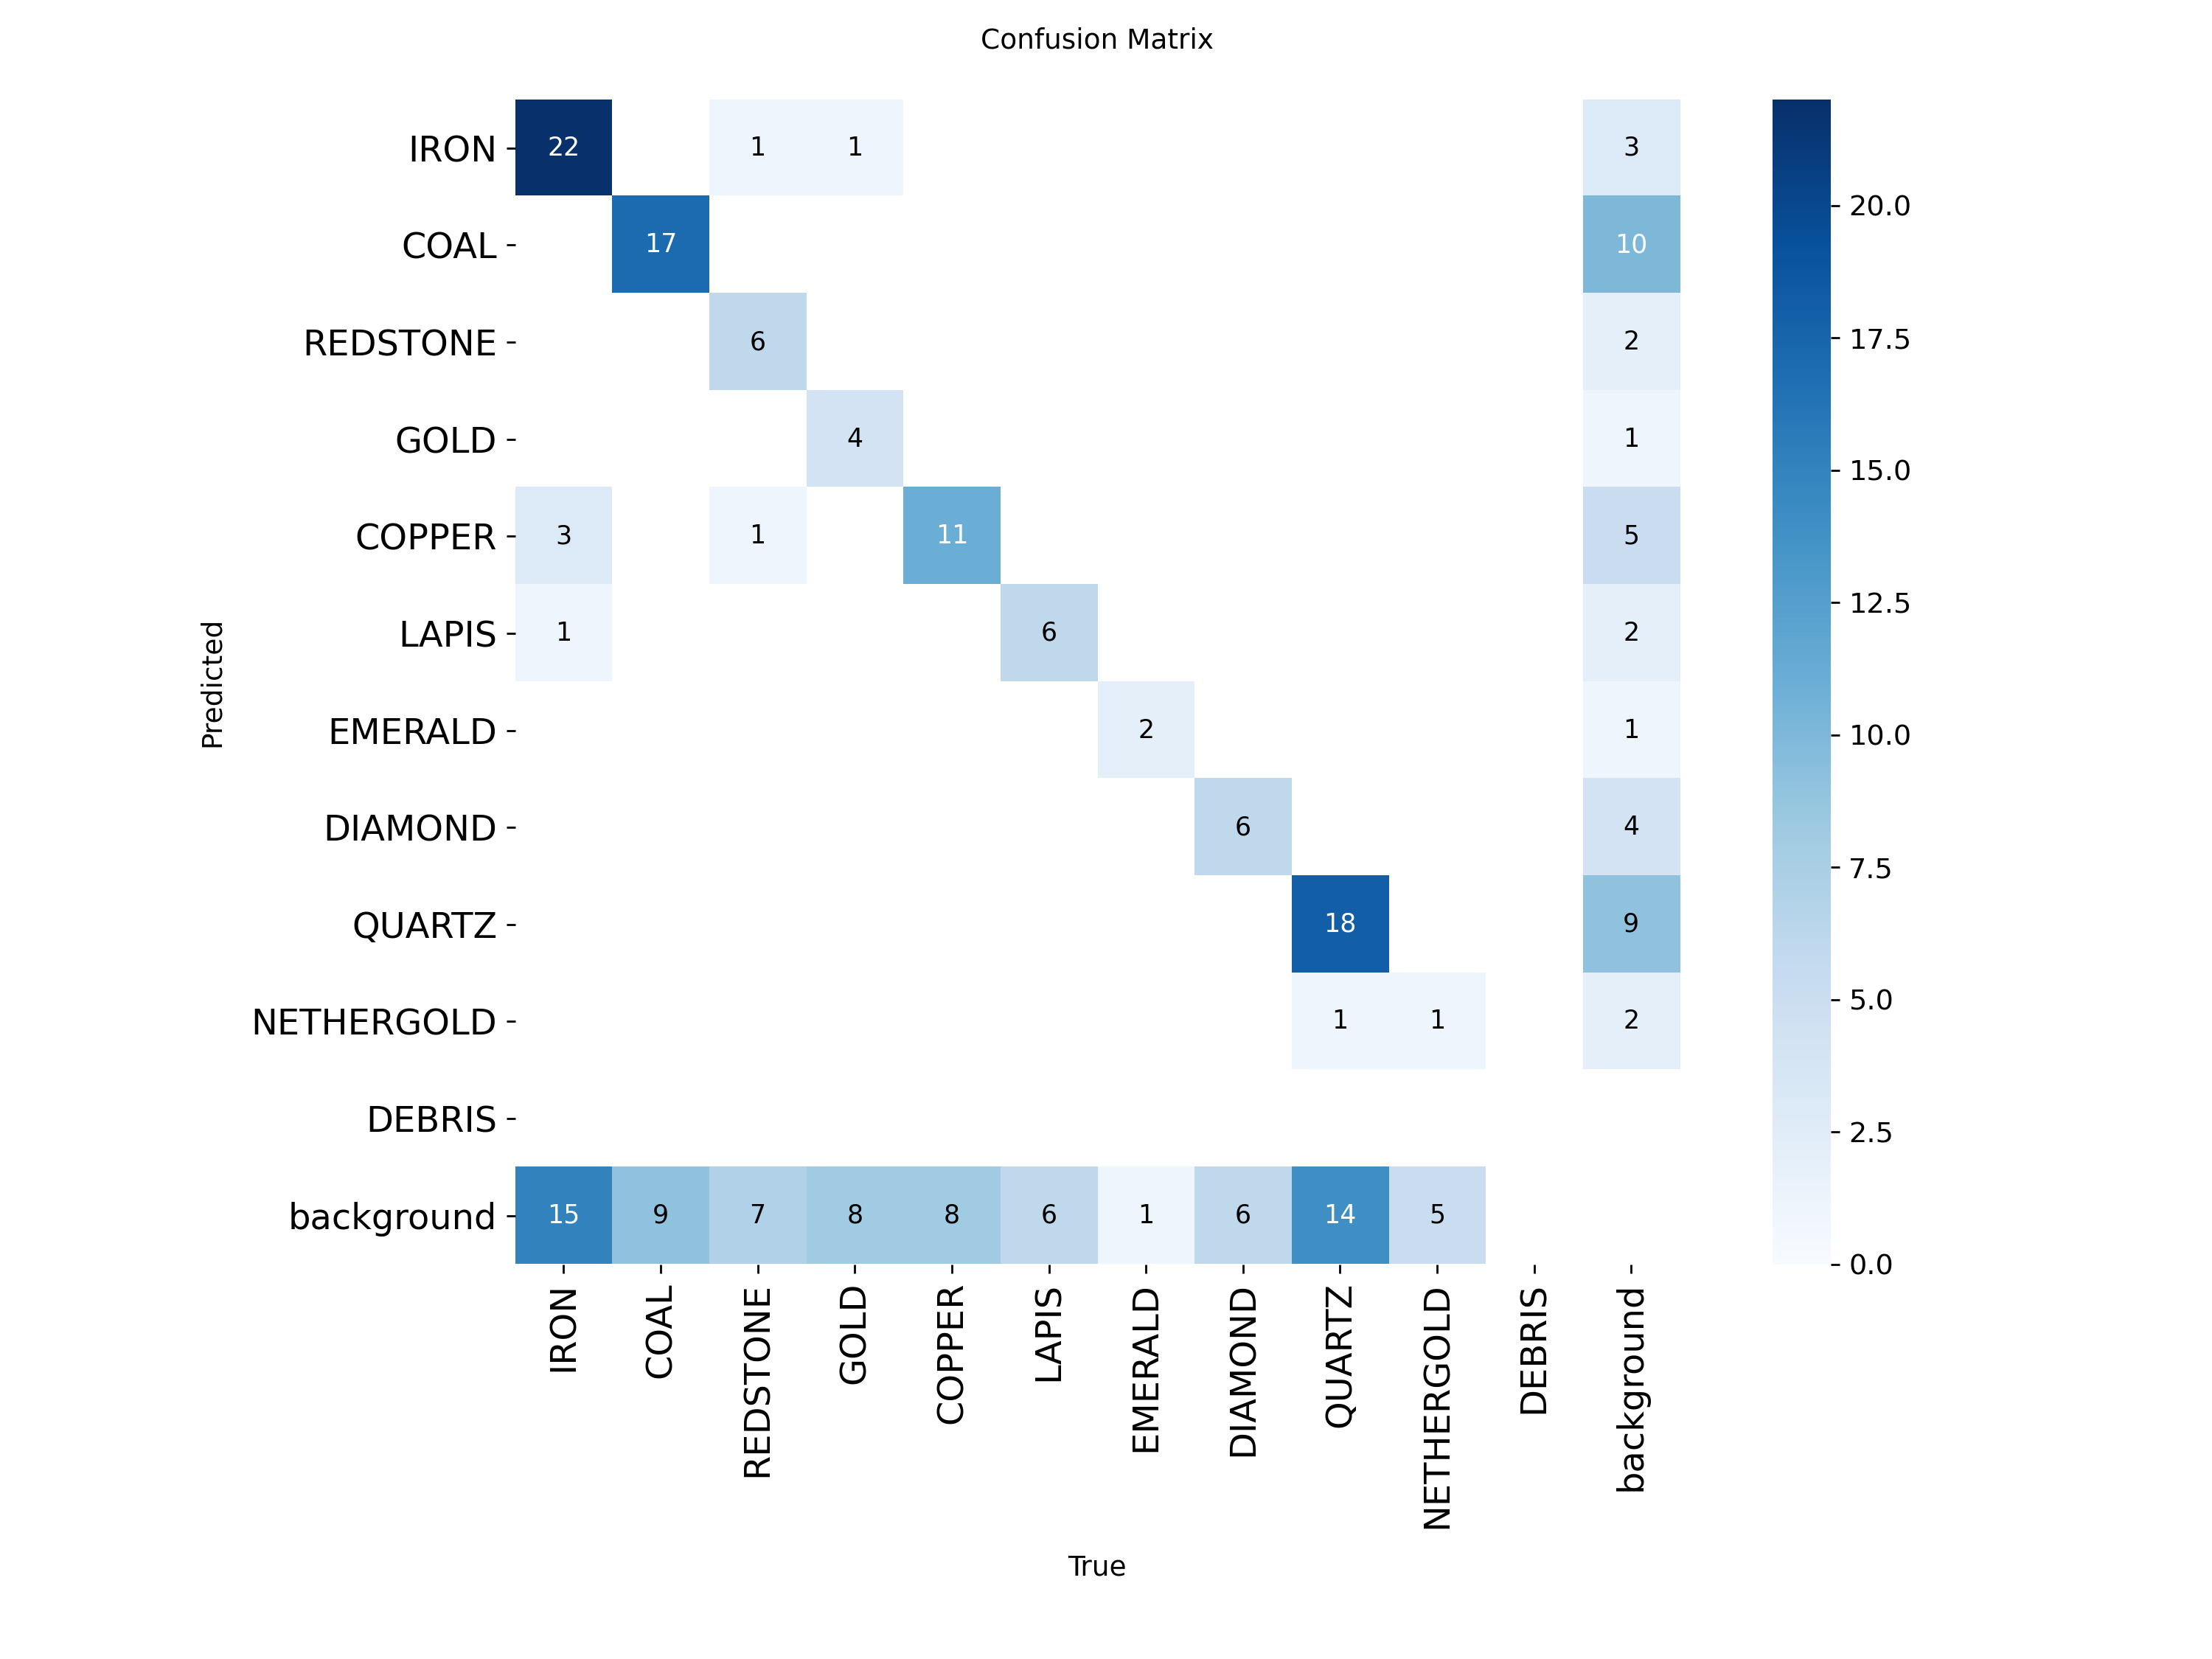

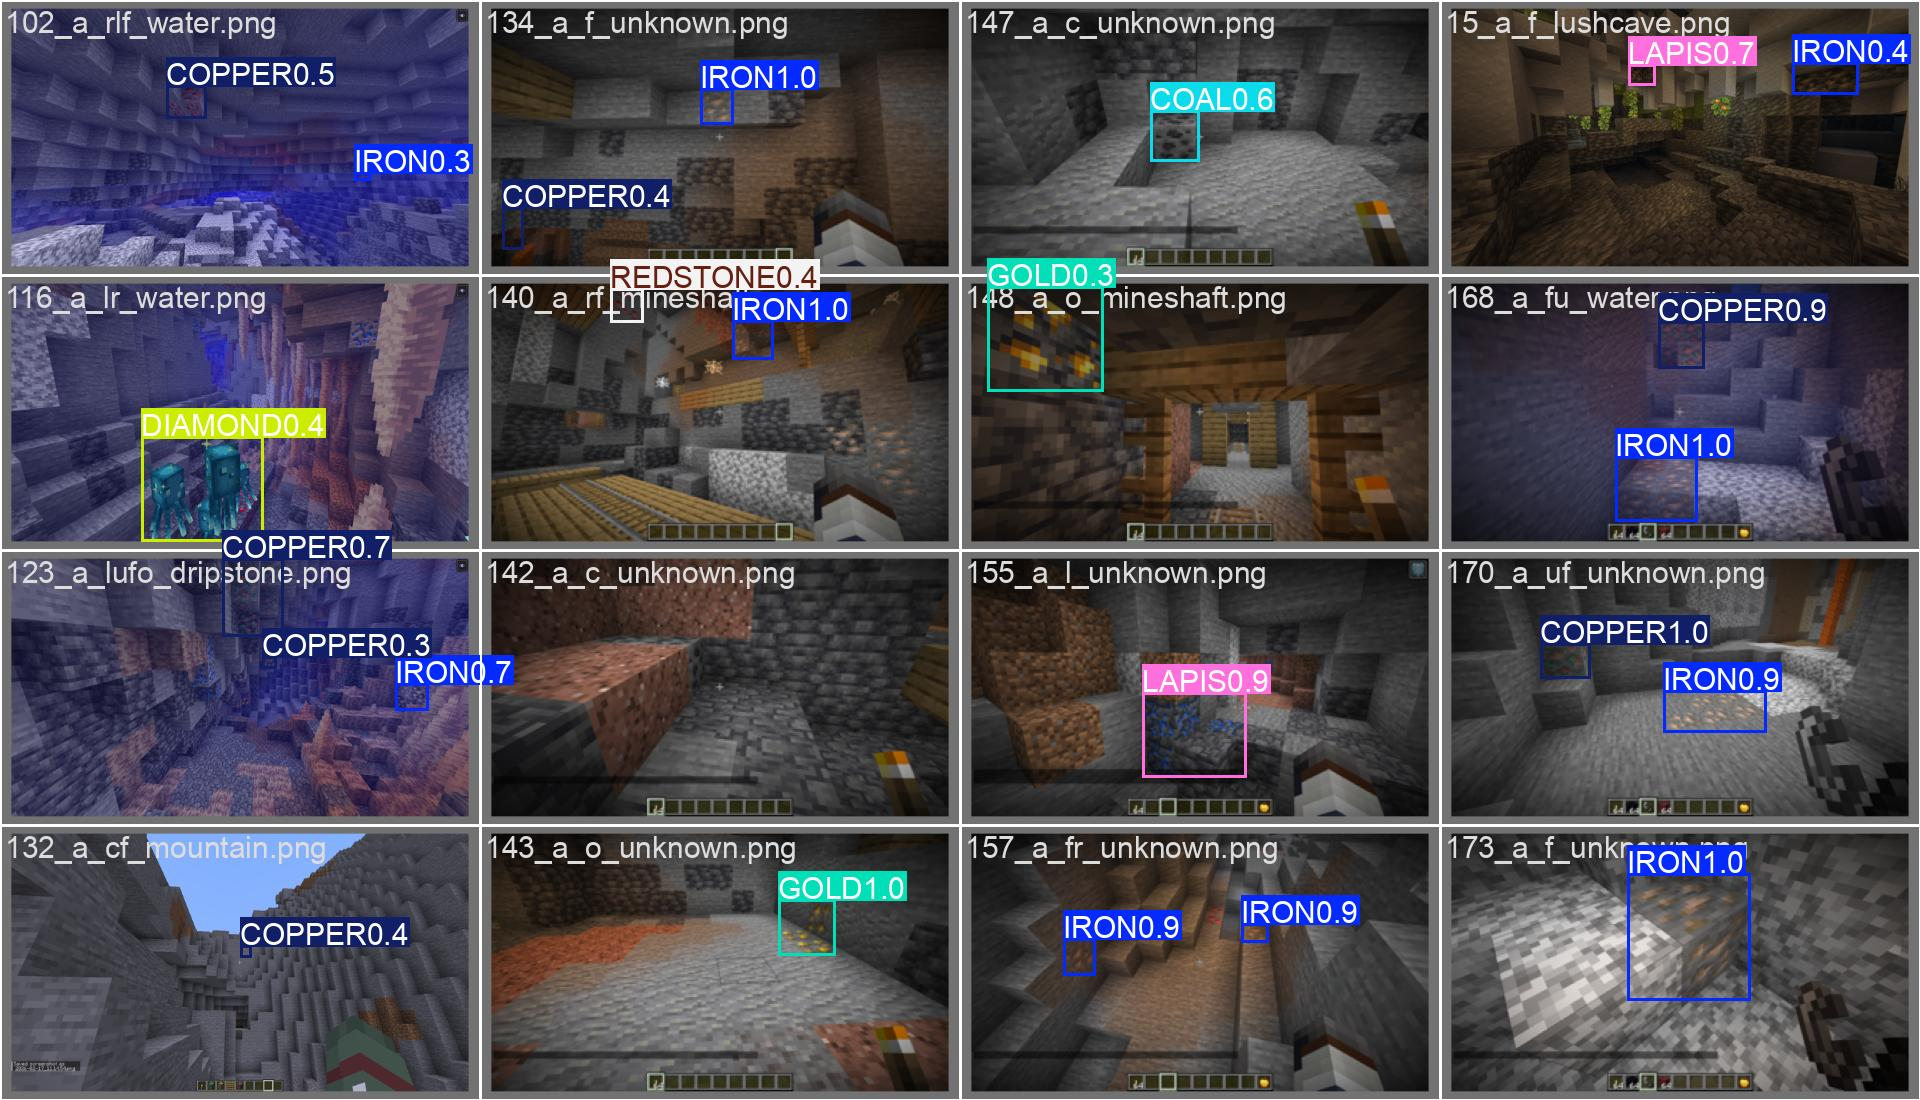

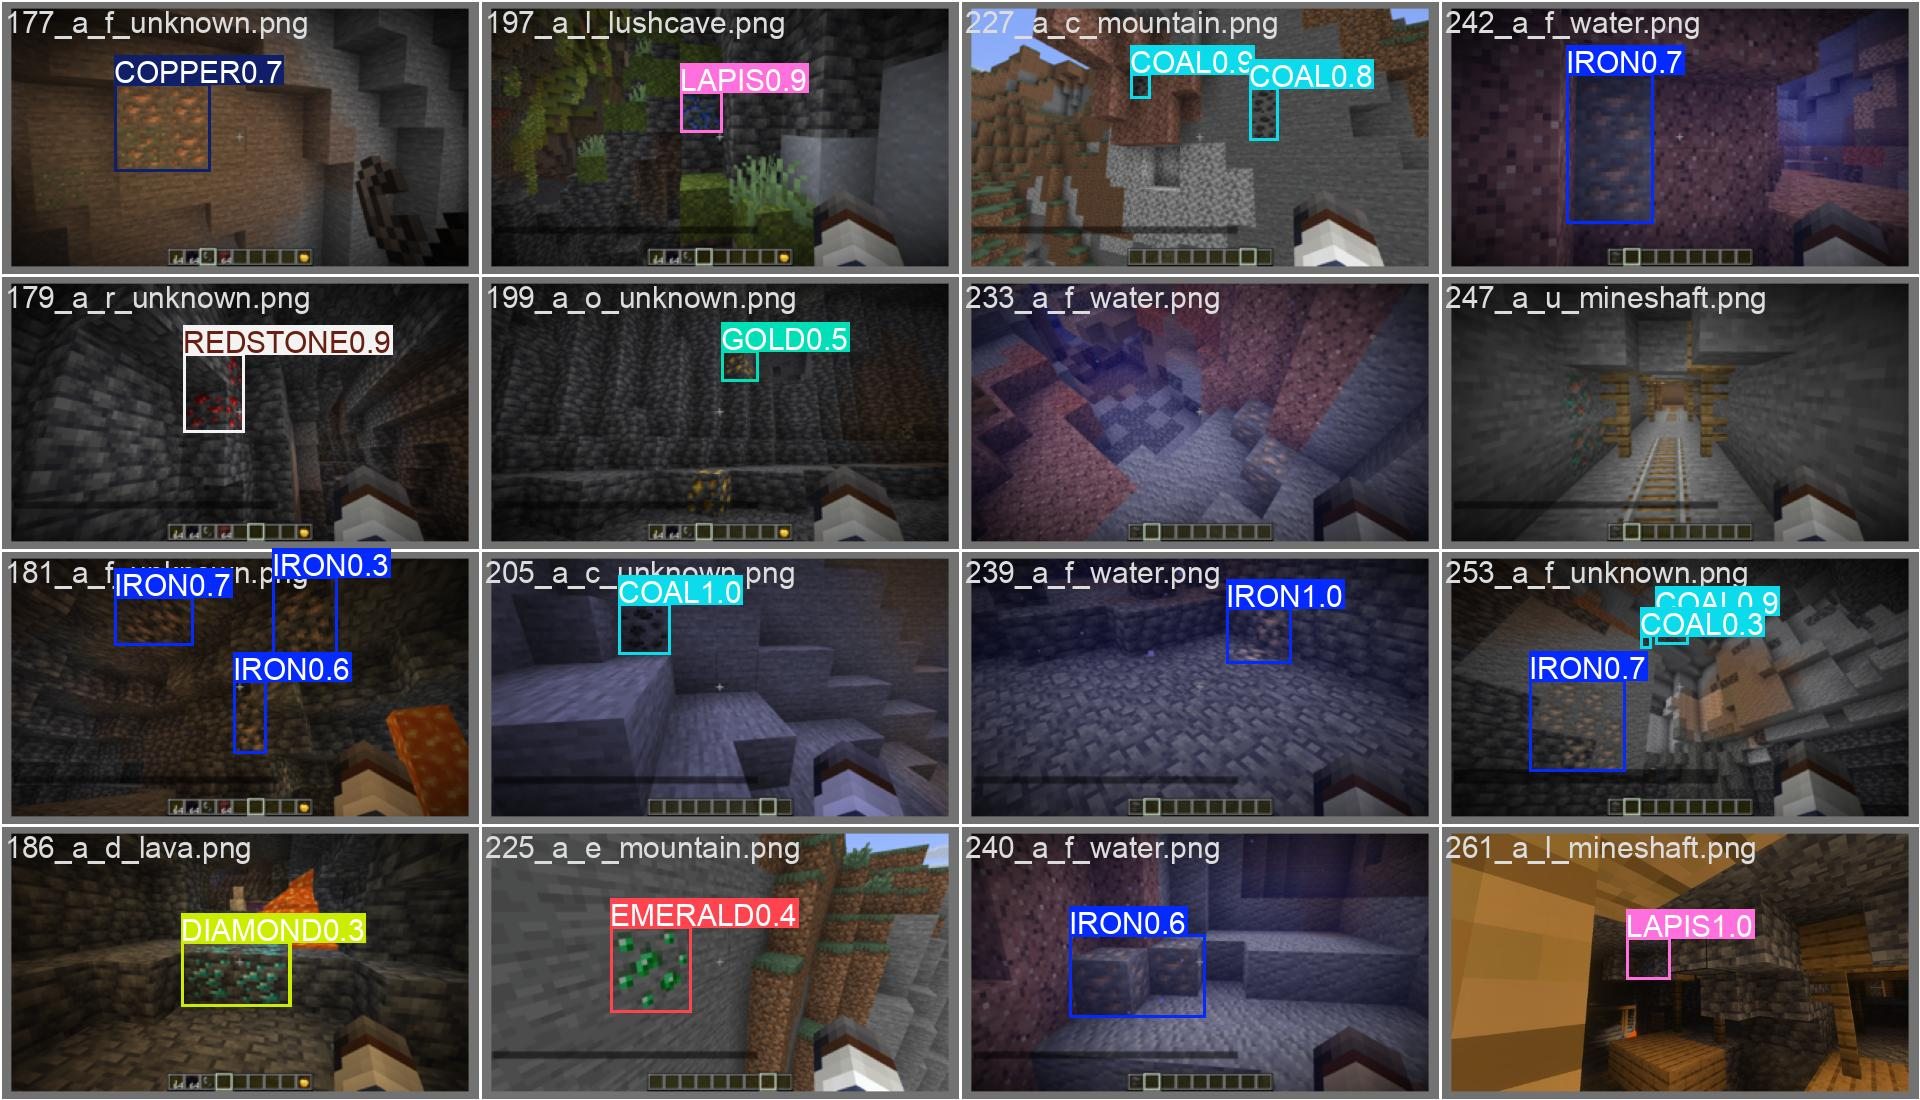

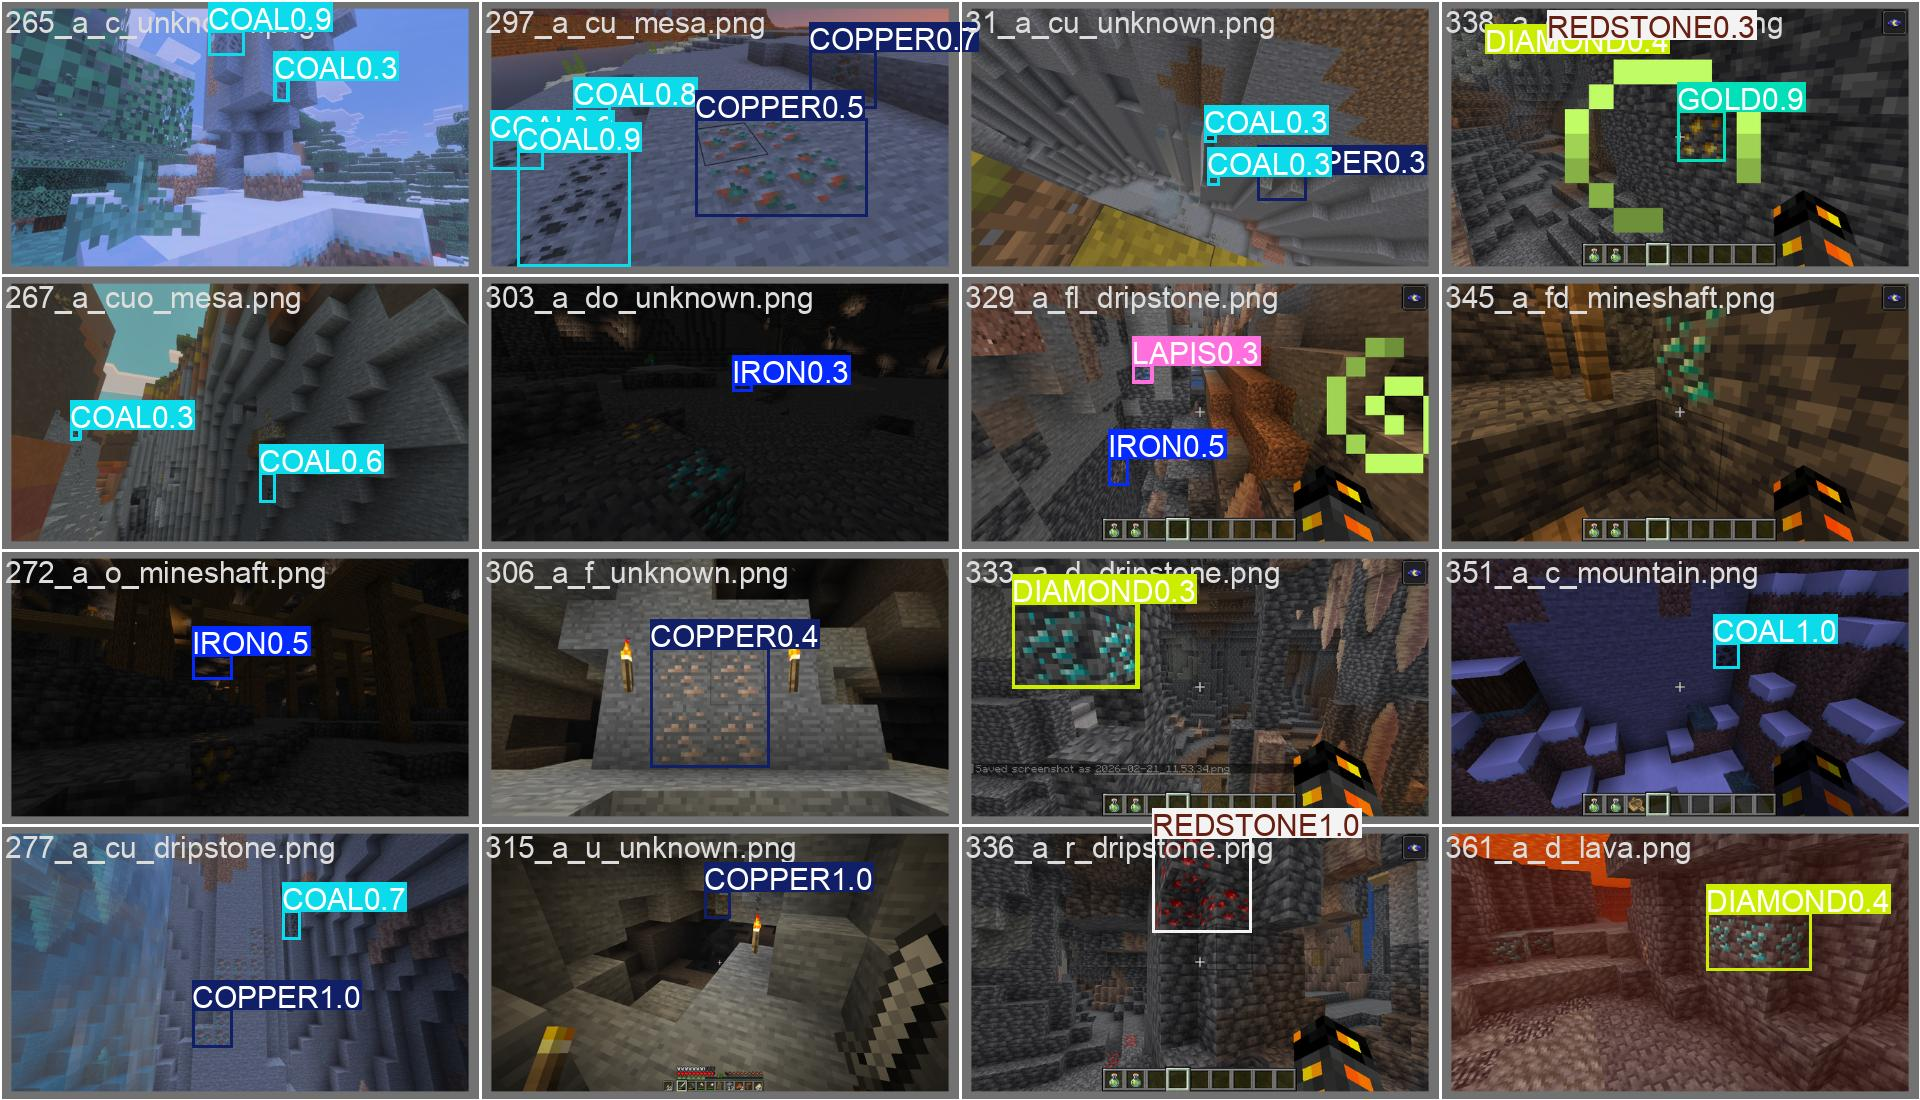

Precision : 0.6350197804019014
Rappel : 0.5194151824019071
F1-Score : 0.571429185175029
mAP@50-95: 0.381


In [ ]:
from IPython.display import Image, display

#!ls runs/detect/train
#!ls runs/detect/val

display(Image(filename='runs/detect/train/results.png', width=800))
display(Image(filename='runs/detect/val/confusion_matrix.png', width=800))
display(Image(filename='runs/detect/val/val_batch0_pred.jpg', width=800))
display(Image(filename='runs/detect/val/val_batch1_pred.jpg', width=800))
display(Image(filename='runs/detect/val/val_batch2_pred.jpg', width=800))

analyse_resultat(results)